## Install Dependencies

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

%cd /content
!rm -rf Single_Cell_Aging_Prediction_LLaMA-Factory
!git clone https://github.com/HangYu8123/Single_Cell_Aging_Prediction_LLaMA-Factory.git


Mounted at /content/drive
/content
Cloning into 'Single_Cell_Aging_Prediction_LLaMA-Factory'...
remote: Enumerating objects: 25656, done.
remote: Total 25656 (delta 0), reused 0 (delta 0), pack-reused 25656 (from 1)
Receiving objects: 100% (25656/25656), 1.12 GiB | 41.66 MiB/s, done.
Resolving deltas: 100% (18454/18454), done.
Updating files: 100% (511/511), done.


In [ ]:
!pip -q install -U \
  "transformers>=4.51.0" \
  "datasets>=2.18.0" \
  "accelerate>=0.33.0" \
  "peft>=0.12.0" \
  "bitsandbytes>=0.43.0" \
  "huggingface_hub>=0.24.0" \
  "evaluate>=0.4.2" \
  "scikit-learn>=1.3.0"

import torch, os, textwrap, random
print("torch:", torch.__version__)
!nvidia-smi -L


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 671.5/671.5 kB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 228.4 MB/s eta 0:00:00
torch: 2.9.0+cpu
/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
# =========================
import os, sys, subprocess

# [CHANGED] Required for PyTorch/XLA on TPUs (PJRT runtime)
os.environ["PJRT_DEVICE"] = "TPU"
# [CHANGED] Prefer bf16 on TPUs
os.environ["XLA_USE_BF16"] = "1"

# Optional (debug/perf knobs). Keep defaults unless troubleshooting.
os.environ.setdefault("PT_XLA_DEBUG", "0")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

# Install PyTorch/XLA wheels (Google's index).
# [CHANGED] Removed GPU-only deps (bitsandbytes, flash-attn, etc.)
PYTORCH_VERSION = "2.6.0"  # [CHANGED] Use matching torch + torch-xla versions.

def pip_install(args):
    print("pip", " ".join(args))
    subprocess.check_call([sys.executable, "-m", "pip"] + args)

# If torch_xla isn't present (or wrong), install matching torch + torch_xla.
try:
    import torch_xla  # noqa: F401
    import torch  # noqa: F401
    print("torch:", torch.__version__)
    print("torch_xla:", torch_xla.__version__)
except Exception as e:
    print("Installing torch/torch_xla because import failed:", repr(e))
    pip_install([
        "-q", "install",
        f"torch=={PYTORCH_VERSION}",
        f"torch_xla[tpu]=={PYTORCH_VERSION}",
        "-f", "https://storage.googleapis.com/libtpu-releases/index.html",
    ])

# Core ML libs
pip_install(["-q", "install", "-U",
            "transformers>=4.45.0",
            "datasets>=2.19.0",
            "scikit-learn>=1.3.0",
            "peft>=0.12.0",
            "evaluate>=0.4.2"])

print("✅ Setup done. If you just installed torch_xla, a **Runtime restart** may be required in Colab.")


torch: 2.9.0+cpu
torch_xla: 2.9.0
pip -q install -U transformers>=4.45.0 datasets>=2.19.0 scikit-learn>=1.3.0 peft>=0.12.0 evaluate>=0.4.2
✅ Setup done. If you just installed torch_xla, a **Runtime restart** may be required in Colab.


In [ ]:
import os
os.environ["PJRT_DEVICE"] = "TPU"
os.environ["XLA_USE_BF16"] = "1"

import torch
import torch_xla
import torch_xla.runtime as xr
import torch_xla.core.xla_model as xm

# Enable SPMD BEFORE touching devices
xr.use_spmd()

print("torch:", torch.__version__)
print("torch_xla:", torch_xla.__version__)
print("PJRT device:", os.environ.get("PJRT_DEVICE"))
print("Global runtime device count:", xr.global_runtime_device_count())
print("XLA device:", torch_xla.device())

if not hasattr(torch, "xla"):
    torch.xla = torch_xla

import torch.utils.checkpoint
import torch_xla.utils.checkpoint as xla_ckpt
torch.utils.checkpoint.checkpoint = xla_ckpt.checkpoint

# Ensure all matplotlib figures render inline in the output cell
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({
    "figure.dpi":       120,
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
})
print("matplotlib backend:", matplotlib.get_backend())


torch: 2.9.0+cpu
torch_xla: 2.9.0
PJRT device: TPU
Global runtime device count: 1
XLA device: xla:0
matplotlib backend: module://matplotlib_inline.backend_inline


In [ ]:
import os, subprocess

REPO_URL = "https://github.com/Ha-ya/Single_Cell_Aging_Prediction_LLaMA-Factory.git"
TARGET_DIR = "/content/Single_Cell_Aging_Prediction_LLaMA-Factory"

if not os.path.exists(TARGET_DIR):
    subprocess.check_call(["git", "clone", REPO_URL, TARGET_DIR])
else:
    print("Repo already exists:", TARGET_DIR)

DATA_DIR = f"{TARGET_DIR}/data"
print("DATA_DIR:", DATA_DIR)


# ======= Code Cell 5 =======
# =========================
# 1) USER SETTINGS
# =========================
import os, random
import numpy as np
import torch

MODEL_ID  = "Ha-ya/QWEN3-1.7B-EIGHT-ORGANS-GENE-ONLY-EXTENDED-1K"

TRAIN_PARTS = list(range(1, 1))   # 1..10
EVAL_PART   = 11                   # 11

# [CHANGED] TPU-friendly defaults:
# - keep MAX_LENGTH conservative; increase only if it fits.
MAX_LENGTH = 1024 * 1
NUM_EPOCHS = 2
LR = 1e-4
WEIGHT_DECAY = 0.0
WARMUP_RATIO = 0.03

# In SPMD mode Trainer runs in a single process, and XLA partitions/shards across TPU cores.
# [CHANGED] Treat batch sizes as GLOBAL batch sizes.
GLOBAL_TRAIN_BS = 128
GLOBAL_EVAL_BS  = 128
GRAD_ACCUM_STEPS = 1

SEED = 42

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(SEED)

# [CHANGED] On TPU, use bf16
DTYPE = torch.bfloat16
print("DTYPE:", DTYPE)

Repo already exists: /content/Single_Cell_Aging_Prediction_LLaMA-Factory
DATA_DIR: /content/Single_Cell_Aging_Prediction_LLaMA-Factory/data
DTYPE: torch.bfloat16


In [ ]:
import glob
print("Files found:", len(glob.glob(f"{DATA_DIR}/*.json")))
print("Example files:", sorted(glob.glob(f"{DATA_DIR}/*.json"))[:5])

# =========================
# 3) Load JSON datasets — ALL parts (1–11) per organ for gradient analysis
# =========================
from datasets import load_dataset, Dataset, DatasetDict
import json

ALL_PARTS = list(range(1, 12))  # parts 1..11 (train + eval combined)

def load_json_dataset(files):
    try:
        return load_dataset("json", data_files=files, split="train")
    except Exception as e:
        print("load_dataset(json) failed; falling back to manual JSON load. Error:", e)
        rows = []
        for fp in files:
            with open(fp, "r") as f:
                obj = json.load(f)   # expects JSON array
                rows.extend(obj)
        return Dataset.from_list(rows)

# --- Per-organ file lists (all 11 parts) ---
def organ_files(organ_name, parts=ALL_PARTS):
    """Return file paths for a given organ across all parts."""
    return [f"{DATA_DIR}/{organ_name}_celldata_part_{i}_gene_only.json" for i in parts]

bladder_files = organ_files("bladder")
brain_files   = organ_files("brain")
bone_files    = organ_files("bone-marrow")
limb_files    = organ_files("limb-muscle")
kidney_files  = organ_files("kidney")
liver_files   = organ_files("liver")
lung_files    = organ_files("lung")
heart_files   = organ_files("heart")

# --- Load all organs ---
bladder_ds = load_json_dataset(bladder_files)
brain_ds   = load_json_dataset(brain_files)
bone_ds    = load_json_dataset(bone_files)
limb_ds    = load_json_dataset(limb_files)
kidney_ds  = load_json_dataset(kidney_files)
liver_ds   = load_json_dataset(liver_files)
lung_ds    = load_json_dataset(lung_files)
heart_ds   = load_json_dataset(heart_files)

# Combined validation split = all organs, all parts
all_files = (bladder_files + brain_files + bone_files + limb_files +
             kidney_files + liver_files + lung_files + heart_files)
eval_ds = load_json_dataset(all_files)

raw = DatasetDict({
    "validation": eval_ds,
    "bladder": bladder_ds,
    "brain": brain_ds,
    "bone": bone_ds,
    "limb": limb_ds,
    "kidney": kidney_ds,
    "liver": liver_ds,
    "lung": lung_ds,
    "heart": heart_ds,
})

print(raw)
print("Columns:", raw["validation"].column_names)
print("Example output label:", raw["validation"][0].get("output"))
print(f"\nPer-organ sizes:")
for split in ["bladder", "brain", "bone", "limb", "kidney", "liver", "lung", "heart"]:
    print(f"  {split}: {len(raw[split])} samples")
print(f"  TOTAL validation: {len(raw['validation'])} samples")


Files found: 299
Example files: ['/content/Single_Cell_Aging_Prediction_LLaMA-Factory/data/bladder_cell_data_part_1.json', '/content/Single_Cell_Aging_Prediction_LLaMA-Factory/data/bladder_cell_data_part_10.json', '/content/Single_Cell_Aging_Prediction_LLaMA-Factory/data/bladder_cell_data_part_10_sorted_noorgan.json', '/content/Single_Cell_Aging_Prediction_LLaMA-Factory/data/bladder_cell_data_part_11.json', '/content/Single_Cell_Aging_Prediction_LLaMA-Factory/data/bladder_cell_data_part_11_sorted_noorgan.json']


Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

...

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Resolving data files:   0%|          | 0/88 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    validation: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 94239
    })
    bladder: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 7615
    })
    brain: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 19154
    })
    bone: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 25169
    })
    limb: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 17396
    })
    kidney: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 7262
    })
    liver: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 3859
    })
    lung: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 8992
    })
    heart: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 4792
    })
})
Columns: ['instruction', 'inp

In [ ]:
LABEL2ID = {"1m": 0, "3m": 1, "18m": 2, "24m": 3, "30m":4 }
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

def format_text(example):
    instruction = (example.get("instruction") or "").strip()
    inp = (example.get("input") or "").strip()

    prefix = instruction + "\n\n"
    suffix = "\n\nAnswer with exactly one label from {1m, 3m, 18m, 24m, 30m}."
    text = prefix + inp + suffix

    inp_start_char = len(prefix)
    inp_end_char   = len(prefix) + len(inp)

    y = (example.get("output") or "").strip()
    if y not in LABEL2ID:
        raise ValueError(f"Unexpected label: {y}")
    return {"text": text, "label": LABEL2ID[y],
            "inp_start_char": inp_start_char, "inp_end_char": inp_end_char}

raw = raw.map(format_text, remove_columns=raw["validation"].column_names)
print(raw["validation"][0])

Map:   0%|          | 0/94239 [00:00<?, ? examples/s]

Map:   0%|          | 0/7615 [00:00<?, ? examples/s]

Map:   0%|          | 0/19154 [00:00<?, ? examples/s]

Map:   0%|          | 0/25169 [00:00<?, ? examples/s]

Map:   0%|          | 0/17396 [00:00<?, ? examples/s]

Map:   0%|          | 0/7262 [00:00<?, ? examples/s]

Map:   0%|          | 0/3859 [00:00<?, ? examples/s]

Map:   0%|          | 0/8992 [00:00<?, ? examples/s]

Map:   0%|          | 0/4792 [00:00<?, ? examples/s]

{'text': 'We will give you a sequence of scRNA transcriptomics data of a single cell. We would like to predict the age of the cell based on the gene name. The age is usually decided by combination of genes. The following are the gene names (Genes), gender (Gender), cell type (Class), and organ (Tissue), separated by the keywords Genes, Gender, Class, and Tissue. Different cell type (Class) has different combinations from each other.\n\nGenes:  Fau  Tpt1  Rps10  Rpl28  Rps14  Pnp  Olfml3  Plxdc2  Gadd45g  Dcn  Tubb6  Akap2  Serping1  Col4a2  Hk2  Igfbp6  Crispld2  Pcolce  Il4ra  Rarres2  2010002N04Rik  Lhfp  Mmp2  Col1a1  Ang  Col6a1  Tgfbr1  Prelp  Erf  Pdpn  Tceal8  Cd302  Col6a2  C1s  Ugcg  Col6a3  Aebp1  Fbln5  Itih5  Srxn1  C1ra  Ccdc80  Cxcl14  Lamb2  Arnt  Ptp4a1  Col5a2  Slc7a8  Serpine1  Il6  Fosl1  Gfpt2  Tgfbr3  Efemp2  Crtap  Jam3  Tnfaip3  Map4k5  Col5a1  Hspa1b  Smoc2  Leprel2  Arsb  Ptgis  Slc25a33  Pde3b  Gas6  Ltbp3  Pkd2  Copz2  Phldb2  Mzt2  Ddr2  Plk2  Rab34  Mustn1 

In [ ]:
# =========================
# 5a) Tokenizer + dataset tokenization  ← run this independently to restore tok
# =========================
import inspect
import numpy as np
import torch
import torch_xla
import torch_xla.core.xla_model as xm
import torch_xla.runtime as xr
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding
from peft import LoraConfig, get_peft_model

xr.use_spmd()
print("SPMD devices:", xr.global_runtime_device_count(), "current:", torch_xla.device())

# --------------------------
# Tokenizer
# --------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True, trust_remote_code=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"
if tokenizer.bos_token_id is None and tokenizer.eos_token_id is not None:
    tokenizer.bos_token = tokenizer.eos_token

print("Tokenizer pad_token:", tokenizer.pad_token)
print("Tokenizer vocab size:", tokenizer.vocab_size)

# --------------------------
# Tokenize all organs (fixed-length → stable XLA graph shapes)
# This is fast (~seconds). Keep it in its own cell so you can re-run it
# after a crash without waiting for model reload.
# --------------------------
def tok_fn(batch):
    enc = tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding="max_length",
        return_offsets_mapping=True,
    )
    # Build inp_token_mask: 1 for tokens overlapping the inp region, 0 otherwise
    inp_token_masks = []
    for i in range(len(batch["text"])):
        s = batch["inp_start_char"][i]
        e = batch["inp_end_char"][i]
        offsets = enc["offset_mapping"][i]
        mask = []
        for (tok_s, tok_e) in offsets:
            # Token overlaps with inp char range [s, e) if tok_s < e and tok_e > s
            if tok_s < e and tok_e > s:
                mask.append(1)
            else:
                mask.append(0)
        inp_token_masks.append(mask)
    enc["inp_token_mask"] = inp_token_masks
    del enc["offset_mapping"]  # not needed downstream
    enc["labels"] = batch["label"]
    return enc

tok = raw.map(tok_fn, batched=True, remove_columns=raw["validation"].column_names)
print("Tokenized splits:", list(tok.keys()))
for split in list(tok.keys()):
    print(f"  {split}: {len(tok[split])} samples")
print("\n✅ tok ready.")

/usr/local/lib/python3.12/dist-packages/torch_xla/runtime.py:201: UserWarning: XLA_USE_SPMD is being deprecated. Use torch_xla.runtime.use_spmd() without setting XLA_USE_SPMD env-var.
  warnings.warn("XLA_USE_SPMD is being deprecated. "


SPMD devices: 1 current: xla:0


config.json:   0%|          | 0.00/1.62k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/15.6M [00:00<?, ?B/s]

...

Map:   0%|          | 0/7262 [00:00<?, ? examples/s]

Map:   0%|          | 0/3859 [00:00<?, ? examples/s]

Map:   0%|          | 0/8992 [00:00<?, ? examples/s]

Map:   0%|          | 0/4792 [00:00<?, ? examples/s]

Tokenized splits: ['validation', 'bladder', 'brain', 'bone', 'limb', 'kidney', 'liver', 'lung', 'heart']
  validation: 94239 samples
  bladder: 7615 samples
  brain: 19154 samples
  bone: 25169 samples
  limb: 17396 samples
  kidney: 7262 samples
  liver: 3859 samples
  lung: 8992 samples
  heart: 4792 samples

✅ tok ready.


In [ ]:
# =========================
# 5b) Model + LoRA loading  ← run AFTER 5a; safe to re-run alone after crash
# =========================

def guess_lora_targets(model: torch.nn.Module):
    common = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
    present = set()
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Linear):
            for k in common:
                if name.endswith(k):
                    present.add(k)
    if not present:
        present = {"q_proj", "v_proj"}
    return sorted(present)

# --------------------------
# Model load
# --------------------------
model_kwargs = dict(
    num_labels=len(LABEL2ID),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    trust_remote_code=True,
)
sig = inspect.signature(AutoModelForSequenceClassification.from_pretrained)
model_kwargs["dtype" if "dtype" in sig.parameters else "torch_dtype"] = DTYPE

model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID, **model_kwargs)

model.config.use_cache = False
model.config.pad_token_id = tokenizer.pad_token_id
if getattr(model.config, "bos_token_id", None) is None and tokenizer.bos_token_id is not None:
    model.config.bos_token_id = tokenizer.bos_token_id
if hasattr(model, "generation_config") and getattr(model.generation_config, "bos_token_id", None) is None:
    model.generation_config.bos_token_id = tokenizer.bos_token_id

print("Model loaded:", MODEL_ID, "| num_labels:", model.config.num_labels)

# --------------------------
# LoRA adapters
# --------------------------
lora_targets = sorted(set(guess_lora_targets(model) + ["embed_tokens"]))
print("LoRA target_modules:", lora_targets)

lora_config = LoraConfig(
    r=32, lora_alpha=64, lora_dropout=0.05, bias="none",
    task_type="SEQ_CLS", target_modules=lora_targets,
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# gradient_checkpointing intentionally OFF: use_reentrant=True on XLA breaks
# gradient flow to inputs_embeds — not needed for saliency inference anyway.
model.config.use_cache = False

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, pad_to_multiple_of=128)

# Move to XLA device
device = torch_xla.device()
model = model.to(device)
torch_xla.sync()
print(f"Model on device: {device}")
print("\n✅ Model + LoRA ready for inference.")


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.53G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Model loaded: Ha-ya/QWEN3-1.7B-EIGHT-ORGANS-GENE-ONLY-EXTENDED-1K | num_labels: 5
LoRA target_modules: ['down_proj', 'embed_tokens', 'gate_proj', 'k_proj', 'o_proj', 'q_proj', 'up_proj', 'v_proj']
trainable params: 40,522,048 || all params: 1,807,134,016 || trainable%: 2.2423
Model on device: xla:0

✅ Model + LoRA ready for inference.


In [ ]:
# ==============================
# FINAL EVAL + VISUALIZE: ALL + SUBCATEGORIES (together, reuse logits)
# ==============================

import os, json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def _get_logits(predictions):
    # Some models return tuple/list; keep logits only
    if isinstance(predictions, (tuple, list)):
        return predictions[0]
    return predictions

labels_sorted = sorted(list(ID2LABEL.keys()))
label_names = [ID2LABEL[i] for i in labels_sorted]

# ------------------------------
# Subset -> validation index mapping helpers
# ------------------------------

_ID_CANDIDATES = ["id", "idx", "guid", "example_id", "uid", "record_id"]

def _try_get_indices_from__indices(subset_ds):
    """
    If subset_ds was produced from a parent dataset via .select/.filter,
    HF Datasets often stores the parent indices in subset_ds._indices.
    Returns np.ndarray[int64] or None.
    """
    idx_tbl = getattr(subset_ds, "_indices", None)
    if idx_tbl is None:
        return None

    try:
        # datasets.table.Table supports .column_names and .column(i)
        col_names = getattr(idx_tbl, "column_names", None)
        if col_names and len(col_names) > 0:
            # Prefer a column literally named "indices" if present, else first column
            if "indices" in col_names:
                col = idx_tbl.column(col_names.index("indices"))
            else:
                col = idx_tbl.column(0)
            idx_list = col.to_pylist()
            return np.asarray(idx_list, dtype=np.int64)
    except Exception:
        pass

    # Some versions may store as dict-like
    try:
        if hasattr(idx_tbl, "to_pydict"):
            d = idx_tbl.to_pydict()
            if "indices" in d:
                return np.asarray(d["indices"], dtype=np.int64)
            # fallback: first key
            if len(d) > 0:
                k0 = list(d.keys())[0]
                return np.asarray(d[k0], dtype=np.int64)
    except Exception:
        pass

    return None

def _pick_id_column(ds):
    cols = set(getattr(ds, "column_names", []))
    for c in _ID_CANDIDATES:
        if c in cols:
            return c
    return None

def _try_get_indices_from_id_column(subset_ds, parent_ds):
    """
    If both parent and subset share a stable ID column, build mapping parent_id -> index.
    Returns np.ndarray[int64] or None.
    """
    parent_id_col = _pick_id_column(parent_ds)
    subset_id_col = _pick_id_column(subset_ds)
    if parent_id_col is None or subset_id_col is None or parent_id_col != subset_id_col:
        return None

    id_col = parent_id_col
    try:
        parent_ids = parent_ds[id_col]
        subset_ids = subset_ds[id_col]
    except Exception:
        return None

    # Build parent map (first occurrence wins)
    id2i = {}
    for i, v in enumerate(parent_ids):
        if v not in id2i:
            id2i[v] = i

    idx = []
    missing = 0
    for v in subset_ids:
        if v in id2i:
            idx.append(id2i[v])
        else:
            missing += 1

    if missing > 0:
        # If anything is missing, mapping is unreliable
        return None

    return np.asarray(idx, dtype=np.int64)

def get_subset_indices_in_validation(subset_ds, validation_ds):
    """
    Returns indices into validation_ds corresponding to subset_ds, or None if cannot map.
    """
    idx = _try_get_indices_from__indices(subset_ds)
    if idx is not None:
        return idx

    idx = _try_get_indices_from_id_column(subset_ds, validation_ds)
    if idx is not None:
        return idx

    return None

# ------------------------------
# Core evaluation from arrays (no extra inference)
# ------------------------------

def evaluate_from_arrays(split_name: str, y_true: np.ndarray, logits: np.ndarray, metrics: dict = None):
    """
    Compute confusion matrix, per-label recall (row-wise acc), and classification report
    from already-available y_true and logits.
    """
    y_true = np.asarray(y_true).reshape(-1)
    logits = np.asarray(logits)
    y_pred = np.argmax(logits, axis=-1).reshape(-1)

    cm = confusion_matrix(y_true, y_pred, labels=labels_sorted)

    # Per-label row-wise accuracy == recall from CM
    per_label_acc = {}
    for row_i, lab_id in enumerate(labels_sorted):
        denom = cm[row_i, :].sum()
        per_label_acc[ID2LABEL[lab_id]] = float(cm[row_i, row_i] / denom) if denom > 0 else float("nan")

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=labels_sorted,
        target_names=label_names,
        digits=4,
        output_dict=True,
        zero_division=0,
    )

    # Derived summary metrics (consistent across splits)
    derived = {
        "accuracy": float(report_dict.get("accuracy", float("nan"))),
        "macro_precision": float(report_dict.get("macro avg", {}).get("precision", float("nan"))),
        "macro_recall": float(report_dict.get("macro avg", {}).get("recall", float("nan"))),
        "macro_f1": float(report_dict.get("macro avg", {}).get("f1-score", float("nan"))),
        "weighted_f1": float(report_dict.get("weighted avg", {}).get("f1-score", float("nan"))),
    }

    # Store metrics with a consistent prefix for plotting helpers
    overall_metrics = {}
    if metrics:
        overall_metrics.update(metrics)

    # Ensure we always have an "*accuracy" key for plotting (even for sub-splits)
    overall_metrics[f"final_{split_name}_accuracy"] = derived["accuracy"]
    overall_metrics[f"final_{split_name}_macro_f1"] = derived["macro_f1"]

    return {
        "split": split_name,
        "num_samples": int(len(y_true)),
        "overall_metrics": overall_metrics,
        "derived_metrics": derived,
        "per_label_accuracy_rowwise": per_label_acc,
        "confusion_matrix": {"labels": label_names, "matrix": cm.tolist()},
        "classification_report": report_dict,
    }

def _extract_overall_acc(metrics: dict, report_dict: dict):
    # Prefer trainer metric if present; fallback to classification_report accuracy.
    acc_key = next((k for k in metrics.keys() if k.endswith("accuracy")), None)
    if acc_key is not None and isinstance(metrics.get(acc_key, None), (int, float)):
        return float(metrics[acc_key])
    if "accuracy" in report_dict and isinstance(report_dict["accuracy"], (int, float)):
        return float(report_dict["accuracy"])
    return float("nan")

# ------------------------------
# Plotting (unchanged behavior, now used for each split)
# ------------------------------

def plot_accuracy_f1_recall(split_result: dict, out_dir: str):
    """
    Figure 1:
      - Per-class Recall (row-wise accuracy) + Per-class F1 (grouped bars)
      - Overall accuracy (horizontal line)
      - Macro Recall / Macro F1 (text)
    """
    labels = split_result["confusion_matrix"]["labels"]
    report = split_result["classification_report"]
    metrics = split_result["overall_metrics"]

    recalls = []
    f1s = []
    supports = []
    for lab in labels:
        r = split_result["per_label_accuracy_rowwise"].get(lab, float("nan"))
        recalls.append(r)

        if lab in report:
            f1s.append(float(report[lab].get("f1-score", 0.0)))
            supports.append(int(report[lab].get("support", 0)))
        else:
            f1s.append(0.0)
            supports.append(0)

    recalls_plot = [0.0 if (r is None or not np.isfinite(r)) else float(r) for r in recalls]

    overall_acc = _extract_overall_acc(metrics, report)
    macro_recall = float(report.get("macro avg", {}).get("recall", float("nan")))
    macro_f1 = float(report.get("macro avg", {}).get("f1-score", float("nan")))

    x = np.arange(len(labels))
    width = 0.40

    plt.figure(figsize=(max(10, 0.7 * len(labels)), 6))
    plt.bar(x - width/2, recalls_plot, width, label="Per-class Recall (row-wise acc)")
    plt.bar(x + width/2, f1s, width, label="Per-class F1")

    if np.isfinite(overall_acc):
        plt.axhline(overall_acc, linestyle="--", linewidth=2, label=f"Overall Accuracy = {overall_acc:.4f}")

    xticks = [f"{lab}\n(n={n})" for lab, n in zip(labels, supports)]
    plt.xticks(x, xticks, rotation=45, ha="right")
    plt.ylim(0, 1.05)
    plt.ylabel("Score")
    plt.title(f"[{split_result['split']}] Per-class Recall/F1 + Overall Accuracy")

    text_lines = []
    if np.isfinite(macro_recall):
        text_lines.append(f"Macro Recall: {macro_recall:.4f}")
    if np.isfinite(macro_f1):
        text_lines.append(f"Macro F1: {macro_f1:.4f}")
    if np.isfinite(overall_acc):
        text_lines.append(f"Overall Acc: {overall_acc:.4f}")
    if text_lines:
        plt.gca().text(
            1.01, 0.5,
            "\n".join(text_lines),
            transform=plt.gca().transAxes,
            va="center",
            fontsize=11,
            bbox=dict(boxstyle="round", alpha=0.2),
        )

    plt.legend()
    plt.tight_layout()

    os.makedirs(out_dir, exist_ok=True)
    fig_path = os.path.join(out_dir, f"final_{split_result['split']}_metrics.png")
    plt.savefig(fig_path, dpi=200)
    plt.show()
    print(f"Saved metrics figure to: {fig_path}")

def plot_confusion_matrix(split_result: dict, out_dir: str):
    """
    Figure 2:
      - Confusion matrix with row-normalized heatmap
      - Annotate each cell with: count + normalized value
    """
    labels = split_result["confusion_matrix"]["labels"]
    cm = np.array(split_result["confusion_matrix"]["matrix"], dtype=np.int64)

    row_sums = cm.sum(axis=1, keepdims=True)
    with np.errstate(divide="ignore", invalid="ignore"):
        cm_norm = np.divide(cm, row_sums, where=(row_sums != 0))
        cm_norm = np.nan_to_num(cm_norm)

    plt.figure(figsize=(max(8, 0.6 * len(labels)), max(6, 0.6 * len(labels))))
    im = plt.imshow(cm_norm)  # default colormap is fine
    plt.colorbar(im, fraction=0.046, pad=0.04)

    plt.xticks(np.arange(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(np.arange(len(labels)), labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"[{split_result['split']}] Confusion Matrix (row-normalized colors)")

    for i in range(len(labels)):
        for j in range(len(labels)):
            plt.text(
                j, i,
                f"{cm[i, j]}\n{cm_norm[i, j]:.2f}",
                ha="center", va="center",
                fontsize=9
            )

    plt.tight_layout()

    os.makedirs(out_dir, exist_ok=True)
    fig_path = os.path.join(out_dir, f"final_{split_result['split']}_confusion_matrix.png")
    plt.savefig(fig_path, dpi=200)
    plt.show()
    print(f"Saved confusion matrix figure to: {fig_path}")



In [ ]:
# # ============================================================
# # Interpretability block — quick single-sample check per organ
# # (use_true_label=True: attribute toward ground-truth class)
# # [CHANGED] Only analyse tokens in the inp region (inp_token_mask)
# # ============================================================

# import gc
# import time
# import numpy as np
# import torch
# import matplotlib.pyplot as plt

# import torch_xla
# import torch_xla.core.xla_model as xm

# def _to_device(batch, device):
#     return {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

# def _clean_token(tok_str: str) -> str:
#     return tok_str.replace("▁", " ").replace("Ġ", " ")

# def _topk_tokens(tokens, scores, k=20, exclude_special=True):
#     tokens = list(tokens)
#     scores = np.asarray(scores, dtype=np.float64)
#     keep = []
#     for i, t in enumerate(tokens):
#         tt = t.strip()
#         if tt == "":
#             continue
#         if exclude_special and (tt in {"[PAD]", "<pad>", "<s>", "</s>", "<unk>"}):
#             continue
#         keep.append(i)
#     if len(keep) == 0:
#         keep = list(range(len(tokens)))
#     filt_scores = scores[keep]
#     order = np.argsort(-filt_scores)[: min(k, len(filt_scores))]
#     idx = [keep[i] for i in order]
#     return idx, scores[idx]

# def _barh_plot(title, tokens, scores):
#     order = np.argsort(scores)
#     tokens_s = [tokens[i] for i in order]
#     scores_s = scores[order]
#     plt.figure(figsize=(10, max(5, 0.35 * len(tokens_s))))
#     plt.barh(range(len(tokens_s)), scores_s)
#     plt.yticks(range(len(tokens_s)), tokens_s)
#     plt.xlabel("Importance score")
#     plt.title(title)
#     plt.tight_layout()
#     plt.show()

# organ_keys = ["bladder", "brain", "bone", "limb", "kidney", "liver", "lung", "heart"]

# device = torch_xla.device()
# model.eval()

# for organ in organ_keys:
#     if organ not in tok:
#         print(f"[WARN] '{organ}' not found in tok, skipping.")
#         continue

#     organ_ds = tok[organ]
#     if len(organ_ds) == 0:
#         print(f"[WARN] '{organ}' dataset is empty, skipping.")
#         continue

#     ex = organ_ds[0]

#     input_ids_tensor = torch.tensor([ex["input_ids"]],      dtype=torch.long)
#     attn_mask_tensor = torch.tensor([ex["attention_mask"]], dtype=torch.long)
#     true_label = int(ex["labels"]) if "labels" in ex else None

#     token_strs   = tokenizer.convert_ids_to_tokens(ex["input_ids"])
#     token_strs   = [_clean_token(t) for t in token_strs]
#     attn_mask_np = np.array(ex["attention_mask"], dtype=np.int64)
#     inp_mask_np  = np.array(ex["inp_token_mask"], dtype=np.int64)   # [CHANGED]

#     # ── Gradient × input saliency ──────────────────────────────────────────────
#     t_start = time.perf_counter()

#     input_ids_dev  = input_ids_tensor.to(device)
#     attn_mask_dev  = attn_mask_tensor.to(device)
#     del input_ids_tensor, attn_mask_tensor

#     input_emb_layer = model.get_input_embeddings()
#     embeds = input_emb_layer(input_ids_dev)
#     del input_ids_dev
#     embeds = embeds.detach().clone().requires_grad_(True)

#     out = model(
#         inputs_embeds=embeds,
#         attention_mask=attn_mask_dev,
#         output_attentions=False,
#         output_hidden_states=False,   # ← don't hold 28 layer outputs alive
#         return_dict=True,
#     )
#     del attn_mask_dev

#     logits     = out.logits
#     del out                           # ← release computation graph + other outputs
#     pred_class = int(torch.argmax(logits, dim=-1).item())

#     target_class = true_label if true_label is not None else pred_class
#     target_logit = logits[0, target_class]
#     del logits

#     model.zero_grad(set_to_none=True)
#     target_logit.backward()
#     del target_logit

#     grads = embeds.grad.detach()
#     saliency = (grads * embeds.detach()).float()[0]   # [L, H]
#     grad_scores = torch.norm(saliency, dim=-1).cpu().numpy()
#     del grads, embeds, saliency

#     elapsed = time.perf_counter() - t_start

#     # Mask pads AND non-inp tokens  [CHANGED]
#     grad_scores_masked = grad_scores.copy()
#     grad_scores_masked[attn_mask_np == 0] = -np.inf
#     grad_scores_masked[inp_mask_np  == 0] = -np.inf      # only keep inp region

#     topk = 20
#     grad_top_idx, grad_top_scores = _topk_tokens(token_strs, grad_scores_masked, k=topk)
#     grad_top_tokens = [token_strs[i] for i in grad_top_idx]

#     print("="*60)
#     print(f"[{organ.upper()}] First sample gradient importance (use_true_label=True, inp-only)")
#     print(f"True label: {true_label} ({ID2LABEL.get(true_label, 'NA')})")
#     print(f"Pred label: {pred_class} ({ID2LABEL.get(pred_class, 'NA')})")
#     print(f"Target class for attribution: {target_class} ({ID2LABEL.get(target_class, 'NA')})")
#     print(f"Time: {elapsed:.4f}s")
#     print("="*60)

#     _barh_plot(
#         title=(f"[{organ.upper()}] Gradient×Input (||grad⊙embed||₂, "
#                f"target_class={target_class}) — top {len(grad_top_tokens)} [inp-only]"),
#         tokens=grad_top_tokens,
#         scores=grad_top_scores,
#     )

#     torch_xla.sync()   # flush XLA graph after each organ; prevents graph explosion
#     gc.collect()

# xm.mark_step()

In [ ]:
# ============================================================
# BLOCK 1: Gradient importance analysis — batched, use_true_label=True
# ============================================================
# Key design decisions:
#   - GRAD_BATCH_SIZE = 4 (conservative for 31.25 GB HBM)
#   - use_true_label=True : attribute toward ground-truth class
#   - Batching: transformer Jacobian is block-diagonal across the batch, so
#     d(Σ_b logit[b,target[b]]) / d(embeds[b]) == d(logit[b,target[b]]) / d(embeds[b])
#   - torch_xla.sync() once per batch → ~batch_size× speedup vs per-sample
#   - output_hidden_states=False + explicit del of XLA tensors → no HBM leak
#   - model.zero_grad(set_to_none=True) AFTER backward frees ~3.4 GB param grads
# ============================================================

try:
    from wordcloud import WordCloud
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", "wordcloud"])
    from wordcloud import WordCloud

import gc
import time
import os
from collections import defaultdict, Counter
import numpy as np
import torch
import matplotlib.pyplot as plt

import torch_xla
import torch_xla.core.xla_model as xm

# ── Batch size ────────────────────────────────────────────────────────────────
GRAD_BATCH_SIZE = 8


# ---------- Token cleaning ----------
def _clean_token(tok_str: str) -> str:
    return tok_str.replace("▁", " ").replace("Ġ", " ").strip()


# ---------- Batched gradient importance (memory-safe) ----------
def compute_gradient_importance_batch(model, tokenizer, examples, device,
                                       topk=256, use_true_label=True):
    """
    Compute gradient×input saliency for a batch of examples in ONE forward+backward.

    Memory contract  (revised — aggressively frees CPU + XLA memory)
    ───────────────
    1. Raw embedding tensor (_raw) is separated and deleted before forward pass.
    2. After backward: model.zero_grad(set_to_none=True) frees ~3.4 GB of
       parameter gradients that backward() allocated.
    3. Saliency is computed in a single fused expression (no extra named tensors).
    4. embeds.grad is set to None, then embeds is deleted.
    5. torch_xla.sync() + gc.collect() at the end to force XLA buffer reclamation.
    """
    B = len(examples)

    input_ids_list = [ex["input_ids"]     for ex in examples]
    attn_mask_list = [ex["attention_mask"] for ex in examples]
    inp_mask_list  = [ex["inp_token_mask"] for ex in examples]   # [CHANGED] inp-only mask
    true_labels    = [int(ex["labels"]) if "labels" in ex else None for ex in examples]

    # ── Build XLA tensors ─────────────────────────────────────────────────────
    input_ids_t = torch.tensor(input_ids_list, dtype=torch.long).to(device)
    attn_mask_t = torch.tensor(attn_mask_list, dtype=torch.long).to(device)

    # Embedding lookup — separate raw tensor so we can free it immediately
    _raw = model.get_input_embeddings()(input_ids_t)
    del input_ids_t                                    # ← free: not needed after lookup

    embeds = _raw.detach().clone().requires_grad_(True)  # [B, L, H]
    del _raw                                           # ← free autograd-graph-carrying tensor

    # ── Forward pass ─────────────────────────────────────────────────────────
    out = model(
        inputs_embeds=embeds,
        attention_mask=attn_mask_t,
        output_attentions=False,
        output_hidden_states=False,
        return_dict=True,
    )
    del attn_mask_t

    logits = out.logits
    del out

    pred_classes = torch.argmax(logits, dim=-1).cpu().tolist()

    # ── Determine target class per sample ─────────────────────────────────────
    target_classes = []
    for b in range(B):
        if use_true_label and true_labels[b] is not None:
            target_classes.append(true_labels[b])
        else:
            target_classes.append(pred_classes[b])

    # ── Backward pass ─────────────────────────────────────────────────────────
    target_logit_sum = sum(logits[b, target_classes[b]] for b in range(B))
    del logits

    model.zero_grad(set_to_none=True)                  # free leftover grads from prev batch
    target_logit_sum.backward()
    del target_logit_sum

    # ── Saliency → CPU numpy in one shot, then nuke all XLA refs ─────────────
    with torch.no_grad():
        grad_scores_batch = (embeds.grad * embeds).float().norm(dim=-1).cpu().numpy()

    # Free ~3.4 GB of parameter gradients that backward() just created
    model.zero_grad(set_to_none=True)

    # Break the grad reference, then delete the leaf tensor
    embeds.grad = None
    del embeds

    # Flush XLA lazy graph + force Python GC so the XLA allocator reclaims now
    torch_xla.sync()
    gc.collect()

    # ── Build per-sample results (pure Python/NumPy from here) ────────────────
    results = []
    for b in range(B):
        attn_mask_np       = np.array(attn_mask_list[b], dtype=np.int64)
        inp_mask_np        = np.array(inp_mask_list[b],  dtype=np.int64)   # [CHANGED]
        grad_scores        = grad_scores_batch[b]
        grad_scores_masked = grad_scores.copy()
        grad_scores_masked[attn_mask_np == 0] = -np.inf
        grad_scores_masked[inp_mask_np  == 0] = -np.inf   # [CHANGED] only keep inp region

        token_strs = tokenizer.convert_ids_to_tokens(input_ids_list[b])
        token_strs = [_clean_token(t) for t in token_strs]

        SPECIAL = {"", "[PAD]", "<pad>", "<s>", "</s>", "<unk>", "<|endoftext|>"}
        valid_indices = [
            i for i, t in enumerate(token_strs)
            if t not in SPECIAL and attn_mask_np[i] == 1 and inp_mask_np[i] == 1   # [CHANGED]
        ]

        if not valid_indices:
            results.append(([], [], pred_classes[b], true_labels[b]))
            continue

        valid_scores = grad_scores_masked[valid_indices]
        top_k_local  = min(topk, len(valid_indices))
        top_k_idx    = np.argsort(-valid_scores)[:top_k_local]

        top_tokens = [token_strs[valid_indices[i]] for i in top_k_idx]
        top_scores = valid_scores[top_k_idx].tolist()
        results.append((top_tokens, top_scores, pred_classes[b], true_labels[b]))

    return results


# ---------- Main analysis loop (memory-safe) ----------
def run_gradient_analysis(model, tokenizer, tok, organ_keys,
                           samples_per_organ=None, device=None,
                           batch_size=GRAD_BATCH_SIZE, use_true_label=True):
    """
    Run batched gradient importance analysis on all organs.

    Memory strategy
    ───────────────
    - compute_gradient_importance_batch now handles sync + gc internally
    - Extra gc.collect() every GC_EVERY_N_BATCHES as safety net
    """
    GC_EVERY_N_BATCHES = 1    # gc every batch — critical for preventing RAM drift

    if device is None:
        device = torch_xla.device()
    model.eval()

    organ_freq    = defaultdict(Counter)
    organ_scores  = defaultdict(Counter)
    global_freq   = Counter()
    global_scores = Counter()

    samples_processed = defaultdict(int)
    total_time        = 0.0

    for organ in organ_keys:
        if organ not in tok:
            print(f"[WARN] '{organ}' not found in tok, skipping.")
            continue

        organ_ds  = tok[organ]
        n_samples = len(organ_ds)
        if n_samples == 0:
            print(f"[WARN] '{organ}' dataset is empty, skipping.")
            continue

        n_to_process = n_samples if samples_per_organ is None else min(samples_per_organ, n_samples)
        print(f"[{organ.upper()}] Processing {n_to_process}/{n_samples} samples "
              f"(batch_size={batch_size}, use_true_label={use_true_label})...")

        batch_num = 0
        idx = 0
        while idx < n_to_process:
            batch_end = min(idx + batch_size, n_to_process)
            examples  = [organ_ds[i] for i in range(idx, batch_end)]
            t_start = time.perf_counter()

            batch_results = compute_gradient_importance_batch(
                model, tokenizer, examples, device,
                topk=256, use_true_label=use_true_label,
            )
            # NOTE: torch_xla.sync() + gc.collect() already called inside
            # compute_gradient_importance_batch — no need to sync again here.
            del examples   # ← free raw Python dicts

            elapsed     = time.perf_counter() - t_start
            total_time += elapsed

            # Aggregate
            for top_tokens, top_scores, pred_class, true_label in batch_results:
                for tok_str, score in zip(top_tokens, top_scores):
                    organ_freq[organ][tok_str]   += 1
                    organ_scores[organ][tok_str] += score
                    global_freq[tok_str]          += 1
                    global_scores[tok_str]        += score
                samples_processed[organ] += 1
            del batch_results

            idx       += batch_size
            batch_num += 1

            # Extra safety-net GC (lightweight if nothing to collect)
            if batch_num % GC_EVERY_N_BATCHES == 0:
                gc.collect()

            # Progress log every 50 samples or at end
            if idx % 50 < batch_size or idx >= n_to_process:
                total_so_far   = sum(samples_processed.values())
                avg_per_sample = total_time / total_so_far if total_so_far > 0 else 0.0
                print(f"    [{organ}] {min(idx, n_to_process)}/{n_to_process} done, "
                      f"avg {avg_per_sample:.2f}s/sample")

        # End-of-organ cleanup
        torch_xla.sync()
        gc.collect()
        print(f"  -> [{organ.upper()}] Done. Running total time: {total_time:.2f}s")

    # ── Avg-per-sample normalization (fair cross-organ comparison) ────────────
    organ_scores_avg = {}
    for _organ, _tok_scores in organ_scores.items():
        _n = samples_processed.get(_organ, 1) or 1
        organ_scores_avg[_organ] = Counter({_t: _s / _n for _t, _s in _tok_scores.items()})

    _global_n = sum(samples_processed.values()) or 1
    global_scores_avg = Counter({_t: _s / _global_n for _t, _s in global_scores.items()})

    organ_freq_avg = {}
    for _organ, _tok_freq in organ_freq.items():
        _n = samples_processed.get(_organ, 1) or 1
        organ_freq_avg[_organ] = Counter({_t: _c / _n for _t, _c in _tok_freq.items()})
    global_freq_avg = Counter({_t: _c / _global_n for _t, _c in global_freq.items()})

    return {
        "organ_freq":        dict(organ_freq),
        "organ_scores":      dict(organ_scores),
        "organ_scores_avg":  organ_scores_avg,
        "global_freq":       global_freq,
        "global_scores":     global_scores,
        "global_scores_avg": global_scores_avg,
        "organ_freq_avg":    organ_freq_avg,
        "global_freq_avg":   global_freq_avg,
        "samples_processed": dict(samples_processed),
        "total_time":        total_time,
    }


# ---------- Visualization ----------
def visualize_results(results, organ_keys, out_dir=None):
    """Generate all visualizations from gradient analysis results."""
    organ_freq        = results["organ_freq"]
    organ_scores      = results["organ_scores"]
    global_freq       = results["global_freq"]
    global_scores     = results["global_scores"]
    samples_processed = results["samples_processed"]
    organ_scores_avg  = results.get("organ_scores_avg", {})
    global_scores_avg = results.get("global_scores_avg", Counter())
    organ_freq_avg    = results.get("organ_freq_avg", {})
    global_freq_avg   = results.get("global_freq_avg", Counter())

    if out_dir:
        os.makedirs(out_dir, exist_ok=True)

    print("\n" + "="*60)
    print("VISUALIZATION RESULTS")
    print("="*60)
    print(f"Samples processed: {samples_processed}")
    print(f"Total time: {results['total_time']:.2f}s")

    # # 1. Top 128 tokens by frequency per organ
    # print("\n--- 1. Top 128 tokens by frequency (per organ) ---")
    # for organ in organ_keys:
    #     if organ not in organ_freq:
    #         continue
    #     top_128 = organ_freq[organ].most_common(128)
    #     print(f"\n[{organ.upper()}] Top 128:")
    #     for tok_str, count in top_128[:128]:
    #         print(f"  '{tok_str}': {count}")
    #     if top_128:
    #         tokens = [t for t, _ in top_128[:128]]
    #         counts = [c for _, c in top_128[:128]]
    #         plt.figure(figsize=(16, 12))
    #         plt.barh(range(len(tokens)), counts[::-1])
    #         plt.yticks(range(len(tokens)), tokens[::-1])
    #         plt.xlabel("Frequency in Top-256")
    #         plt.title(f"[{organ.upper()}] Top 128 Tokens by Frequency")
    #         plt.tight_layout()
    #         if out_dir:
    #             plt.savefig(os.path.join(out_dir, f"freq_by_organ_{organ}.png"), dpi=150)
    #         plt.show()

    # 2. Top 128 tokens by frequency (global)
    print("\n--- 2. Top 128 tokens by frequency (all organs) ---")
    top_128_global_freq = global_freq.most_common(128)
    for tok_str, count in top_128_global_freq[:128]:
        print(f"  '{tok_str}': {count}")
    if top_128_global_freq:
        tokens = [t for t, _ in top_128_global_freq[:128]]
        counts = [c for _, c in top_128_global_freq[:128]]
        plt.figure(figsize=(16, 20))
        plt.barh(range(len(tokens)), counts[::-1])
        plt.yticks(range(len(tokens)), tokens[::-1], fontsize=10)
        plt.xlabel("Frequency in Top-256")
        plt.title("[ALL ORGANS] Top 128 Tokens by Frequency")
        plt.tight_layout()
        if out_dir:
            plt.savefig(os.path.join(out_dir, "freq_global.png"), dpi=150)
        plt.show()

    # # 3. Top 128 tokens by total score per organ
    # print("\n--- 3. Top 128 tokens by total score (per organ) ---")
    # organ_top_scores = {}
    # for organ in organ_keys:
    #     if organ not in organ_scores:
    #         continue
    #     top_128 = organ_scores[organ].most_common(128)
    #     organ_top_scores[organ] = top_128
    #     print(f"\n[{organ.upper()}] Top 128:")
    #     for tok_str, score in top_128[:128]:
    #         print(f"  '{tok_str}': {score:.4f}")
    #     if top_128:
    #         tokens = [t for t, _ in top_128[:128]]
    #         scores = [s for _, s in top_128[:128]]
    #         plt.figure(figsize=(16, 20))
    #         plt.barh(range(len(tokens)), scores[::-1])
    #         plt.yticks(range(len(tokens)), tokens[::-1])
    #         plt.xlabel("Total Gradient Score")
    #         plt.title(f"[{organ.upper()}] Top 128 Tokens by Total Score")
    #         plt.tight_layout()
    #         if out_dir:
    #             plt.savefig(os.path.join(out_dir, f"score_by_organ_{organ}.png"), dpi=150)
    #         plt.show()

    # 4. Top 128 tokens by total score (global)
    print("\n--- 4. Top 128 tokens by total score (all organs) ---")
    top_128_global_scores = global_scores.most_common(128)
    for tok_str, score in top_128_global_scores[:128]:
        print(f"  '{tok_str}': {score:.4f}")
    if top_128_global_scores:
        tokens = [t for t, _ in top_128_global_scores[:128]]
        scores = [s for _, s in top_128_global_scores[:128]]
        plt.figure(figsize=(16, 20))
        plt.barh(range(len(tokens)), scores[::-1])
        plt.yticks(range(len(tokens)), tokens[::-1])
        plt.xlabel("Total Gradient Score")
        plt.title("[ALL ORGANS] Top 128 Tokens by Total Score")
        plt.tight_layout()
        if out_dir:
            plt.savefig(os.path.join(out_dir, "score_global.png"), dpi=150)
        plt.show()

    # # 4b. Avg frequency per organ
    # print("\n--- 4b. Avg frequency in top-256 (per organ) ---")
    # for organ in organ_keys:
    #     if organ not in organ_freq_avg: continue
    #     top_f = Counter(organ_freq_avg[organ]).most_common(256)
    #     print(f"\n[{organ.upper()}] Top 128 by avg freq:")
    #     for tok_str, frac in top_f[:128]: print(f"  '{tok_str}': {frac:.4f}")
    #     if top_f:
    #         _tf = [t for t, _ in top_f[:128]]
    #         _ff = [f for _, f in top_f[:128]]
    #         plt.figure(figsize=(16, 20))
    #         plt.barh(range(len(_tf)), _ff[::-1])
    #         plt.yticks(range(len(_tf)), _tf[::-1])
    #         plt.xlabel("Avg freq (fraction in top-256)")
    #         plt.title(f"[{organ.upper()}] Top 128 Tokens — Avg Frequency")
    #         plt.tight_layout()
    #         if out_dir:
    #             plt.savefig(os.path.join(out_dir, f"avg_freq_{organ}.png"), dpi=150)
    #         plt.show()

    # 4c. Avg frequency global
    print("\n--- 4c. Avg frequency in top-256 (global) ---")
    top_gf = global_freq_avg.most_common(256)
    for tok_str, frac in top_gf[:128]: print(f"  '{tok_str}': {frac:.4f}")
    if top_gf:
        _tg = [t for t, _ in top_gf[:128]]
        _fg = [f for _, f in top_gf[:128]]
        plt.figure(figsize=(16, 20))
        plt.barh(range(len(_tg)), _fg[::-1])
        plt.yticks(range(len(_tg)), _tg[::-1])
        plt.xlabel("Avg freq (fraction in top-256)")
        plt.title("[ALL ORGANS] Top 128 Tokens — Avg Frequency")
        plt.tight_layout()
        if out_dir:
            plt.savefig(os.path.join(out_dir, "avg_freq_global.png"), dpi=150)
        plt.show()

    # # 5. Word clouds per organ
    # print("\n--- 5. Word clouds per organ (by total score) ---")
    # for organ in organ_keys:
    #     if organ not in organ_top_scores or len(organ_top_scores[organ]) == 0:
    #         continue
    #     wc_dict = {t: max(s, 1e-6) for t, s in organ_top_scores[organ] if s > 0}
    #     if len(wc_dict) < 5:
    #         print(f"  [{organ}] Not enough positive scores for word cloud, skipping.")
    #         continue
    #     wc = WordCloud(width=800, height=600, background_color="white",
    #                    max_words=100, colormap="viridis")
    #     wc.generate_from_frequencies(wc_dict)
    #     plt.figure(figsize=(16, 12))
    #     plt.imshow(wc, interpolation="bilinear")
    #     plt.axis("off")
    #     plt.title(f"[{organ.upper()}] Word Cloud (Top 100 by Score)")
    #     plt.tight_layout()
    #     if out_dir:
    #         plt.savefig(os.path.join(out_dir, f"wordcloud_{organ}.png"), dpi=150)
    #     plt.show()

    # 6. Word cloud global
    print("\n--- 6. Word cloud (all organs, by total score) ---")
    if top_128_global_scores:
        wc_dict = {t: max(s, 1e-6) for t, s in top_128_global_scores if s > 0}
        if len(wc_dict) >= 5:
            wc = WordCloud(width=800, height=600, background_color="white",
                           max_words=100, colormap="plasma")
            wc.generate_from_frequencies(wc_dict)
            plt.figure(figsize=(16, 12))
            plt.imshow(wc, interpolation="bilinear")
            plt.axis("off")
            plt.title("[ALL ORGANS] Word Cloud (Top 100 by Score)")
            plt.tight_layout()
            if out_dir:
                plt.savefig(os.path.join(out_dir, "wordcloud_global.png"), dpi=150)
            plt.show()

    print("\n" + "="*60)
    print("VISUALIZATION COMPLETE")
    if out_dir:
        print(f"Plots saved to: {out_dir}")
    print("="*60)
    # return organ_top_scores, top_128_global_scores
    return top_128_global_scores


def analyze_organ_specificity(results, organ_keys, topk=100, out_dir=None):
    """
    Identify gene tokens universally important vs. organ-exclusive.
    Uses avg-per-sample scores for fair cross-organ comparison.
    """
    organ_scores_src = results.get("organ_scores_avg") or results.get("organ_scores", {})

    organ_topk_sets = {}
    for organ in organ_keys:
        if organ not in organ_scores_src:
            continue
        top_tokens = [t for t, _ in Counter(organ_scores_src[organ]).most_common(topk)]
        organ_topk_sets[organ] = set(top_tokens)

    if not organ_topk_sets:
        print("[WARN] No organ data found in results.")
        return {}

    token_organ_count = Counter()
    for organ, tok_set in organ_topk_sets.items():
        for t in tok_set:
            token_organ_count[t] += 1

    n_organs  = len(organ_topk_sets)
    universal = [t for t, c in token_organ_count.most_common() if c == n_organs]

    exclusive = {organ: [] for organ in organ_keys}
    for t, c in token_organ_count.items():
        if c == 1:
            for organ, tok_set in organ_topk_sets.items():
                if t in tok_set:
                    exclusive[organ].append(t)
                    break

    print("\n" + "="*60)
    print("ORGAN SPECIFICITY ANALYSIS")
    print("="*60)
    print(f"\nTokens in top-{topk} for ALL {n_organs} organs ({len(universal)} tokens):")
    for t in universal[:30]:
        print(f"  '{t}'")
    print("\nOrgan-exclusive tokens (unique to each organ's top-k):")
    for organ in organ_keys:
        excl = exclusive.get(organ, [])
        print(f"  [{organ.upper()}] {len(excl)} exclusive: {excl[:20]}")

    # Frequency-based specificity
    _ofsrc = results.get("organ_freq_avg") or results.get("organ_freq", {})
    _otfs  = {o: set(t for t, _ in Counter(_ofsrc.get(o, {})).most_common(topk)) for o in organ_keys}
    _tfc   = Counter()
    for _s in _otfs.values():
        for _t in _s: _tfc[_t] += 1
    _no = len([o for o in organ_keys if _otfs.get(o)])
    _uf = [t for t, c in _tfc.most_common() if c == _no]
    _ef = {o: [t for t, c in _tfc.items() if c == 1 and t in _otfs.get(o, set())] for o in organ_keys}
    print("\n--- Frequency-based specificity ---")
    print(f"Universal by freq ({len(_uf)} tokens): {_uf[:30]}")
    print("Exclusive by freq:")
    for o in organ_keys:
        print(f"  [{o.upper()}] {len(_ef.get(o,[]))}: {_ef.get(o,[])[:20]}")

    # Pairwise overlap heatmap
    organ_list = [o for o in organ_keys if o in organ_topk_sets]
    n = len(organ_list)
    if n > 1:
        overlap_matrix = np.zeros((n, n), dtype=int)
        for i in range(n):
            for j in range(n):
                overlap_matrix[i, j] = len(organ_topk_sets[organ_list[i]] & organ_topk_sets[organ_list[j]])

        fig, ax = plt.subplots(figsize=(10, 8))
        im = ax.imshow(overlap_matrix, cmap="YlOrRd")
        ax.set_xticks(range(n)); ax.set_yticks(range(n))
        ax.set_xticklabels(organ_list, rotation=45, ha="right")
        ax.set_yticklabels(organ_list)
        plt.colorbar(im, ax=ax, label=f"# shared tokens in top-{topk}")
        for i in range(n):
            for j in range(n):
                ax.text(j, i, str(overlap_matrix[i, j]), ha="center", va="center", fontsize=10)
        ax.set_title(f"Organ pairwise gene token overlap (top-{topk} by avg gradient score)")
        plt.tight_layout()
        if out_dir:
            os.makedirs(out_dir, exist_ok=True)
            fig_path = os.path.join(out_dir, "organ_token_overlap.png")
            plt.savefig(fig_path, dpi=150)
            print(f"Saved: {fig_path}")
        plt.show()

    return {
        "universal_tokens":  universal,
        "exclusive_tokens":  exclusive,
        "token_organ_count": dict(token_organ_count),
        "organ_topk_sets":   {k: list(v) for k, v in organ_topk_sets.items()},
    }


# # ── TEST RUN: 2 samples per organ ────────────────────────────────────────────
# print("BLOCK 1: TEST RUN (2 samples/organ, batch_size=4, use_true_label=True)")
# print("="*60)

# organ_keys = ["bladder", "brain", "bone", "limb", "kidney", "liver", "lung", "heart"]
# device = torch_xla.device()

# test_results = run_gradient_analysis(
#     model, tokenizer, tok, organ_keys,
#     samples_per_organ=2,
#     device=device,
#     batch_size=GRAD_BATCH_SIZE,
#     use_true_label=True,
# )


# print("\nTest run complete. Run the next cell to visualize, or BLOCK 2 for full analysis.")
# torch_xla.sync()


In [ ]:
# ============================================================
# # BLOCK 1.5: VISUALIZE TEST RESULTS (comment out if not needed)
# # ============================================================

# visualize_results(test_results, organ_keys)
# print("\nVisualization complete. If results look correct, run Block 2 for full analysis.")

In [ ]:
# ============================================================
# BLOCK 2: FULL RUN — All samples from all organs
# ============================================================

# ── Prerequisites check ───────────────────────────────────────────────────────
_missing = [v for v in ["tok", "model", "tokenizer", "GRAD_BATCH_SIZE", "run_gradient_analysis"]
            if v not in globals()]
if _missing:
    raise RuntimeError(
        f"Missing variables: {_missing}\n"
        "Run cells in order: 11 (tokenizer+tok) → 12 (model) → 15 (defines run_gradient_analysis)"
    )
print("✅ Prerequisites OK")

print("="*60)
print("BLOCK 2: FULL RUN (all samples, batch_size=4, use_true_label=True)")
print("="*60)

organ_keys = ["bladder", "brain", "bone", "limb", "kidney", "liver", "lung", "heart"]
device = torch_xla.device()

print("\nDataset sizes (all 11 parts per organ):")
total_samples = 0
for organ in organ_keys:
    if organ in tok:
        n = len(tok[organ])
        print(f"  {organ}: {n}")
        total_samples += n
print(f"  TOTAL: {total_samples}")

print(f"\nStarting full analysis (batch_size={GRAD_BATCH_SIZE})...")
full_results = run_gradient_analysis(
    model, tokenizer, tok, organ_keys,
    samples_per_organ=None,
    device=device,
    batch_size=GRAD_BATCH_SIZE,
    use_true_label=True,
)

print(f"\nFull analysis done. Total time: {full_results['total_time']:.1f}s")
print(f"Samples processed: {full_results['samples_processed']}")


✅ Prerequisites OK
BLOCK 2: FULL RUN (all samples, batch_size=4, use_true_label=True)

Dataset sizes (all 11 parts per organ):
  bladder: 7615
  brain: 19154
  bone: 25169
  limb: 17396
  kidney: 7262
  liver: 3859
  lung: 8992
  heart: 4792
  TOTAL: 94239

Starting full analysis (batch_size=8)...
[BLADDER] Processing 7615/7615 samples (batch_size=8, use_true_label=True)...


[transformers] Qwen3ForSequenceClassification will not detect padding tokens in `inputs_embeds`. Results may be unexpected if using padding tokens in conjunction with `inputs_embeds.`


    [bladder] 56/7615 done, avg 1.66s/sample
    [bladder] 104/7615 done, avg 0.94s/sample
    [bladder] 152/7615 done, avg 0.67s/sample
    [bladder] 200/7615 done, avg 0.83s/sample
    [bladder] 256/7615 done, avg 0.67s/sample
    [bladder] 304/7615 done, avg 0.58s/sample
    [bladder] 352/7615 done, avg 0.51s/sample
    [bladder] 400/7615 done, avg 0.46s/sample
    [bladder] 456/7615 done, avg 0.48s/sample
    [bladder] 504/7615 done, avg 0.50s/sample
    [bladder] 552/7615 done, avg 0.58s/sample
    [bladder] 600/7615 done, avg 0.54s/sample
    [bladder] 656/7615 done, avg 0.50s/sample
    [bladder] 704/7615 done, avg 0.52s/sample
    [bladder] 752/7615 done, avg 0.49s/sample
    [bladder] 800/7615 done, avg 0.47s/sample
    [bladder] 856/7615 done, avg 0.44s/sample
    [bladder] 904/7615 done, avg 0.46s/sample
    [bladder] 952/7615 done, avg 0.44s/sample
    [bladder] 1000/7615 done, avg 0.42s/sample
    [bladder] 1056/7615 done, avg 0.40s/sample
    [bladder] 1104/7615 done, avg

Generating visualizations...

VISUALIZATION RESULTS
Samples processed: {'bladder': 7615, 'brain': 19154, 'bone': 25169, 'limb': 17396, 'kidney': 7262, 'liver': 3859, 'lung': 8992, 'heart': 4792}
Total time: 12250.38s

--- 2. Top 128 tokens by frequency (all organs) ---
  ':': 93723
  'Fth1': 65053
  'Actb': 64236
  'Rps9': 61257
  'Myl6': 54137
  'Serf2': 53444
  'Eif1': 52063
  'Fau': 51893
  'H3f3a': 51217
  'Gabarap': 51095
  'Sat1': 50107
  'Rps29': 49971
  'Tpt1': 46875
  'B2m': 45919
  'Malat1': 45556
  'Gen': 45443
  'Rn45s': 45336
  'Ftl1': 44461
  'Rps10': 43902
  'H2-D1': 43817
  'Itm2b': 40195
  'Ddx5': 39431
  'Ubb': 38264
  'Zfp36': 37433
  'Gpx1': 37222
  'H3f3b': 35771
  'es': 34601
  'Uqcrh': 34204
  'Taldo1': 34051
  'Rpl17': 33401
  'Ucp2': 32528
  'Pabpc1': 31785
  'Rps3': 31469
  'Rps24': 30997
  'Tmbim6': 29804
  'H2afj': 29759
  'Ndufb11': 29684
  'Rps21': 29435
  'Fis1': 29326
  'Tmsb4x': 29273
  'Rpl38': 28322
  'Prr13': 26954
  'Gm1821': 26777
  'Atp5l': 26272


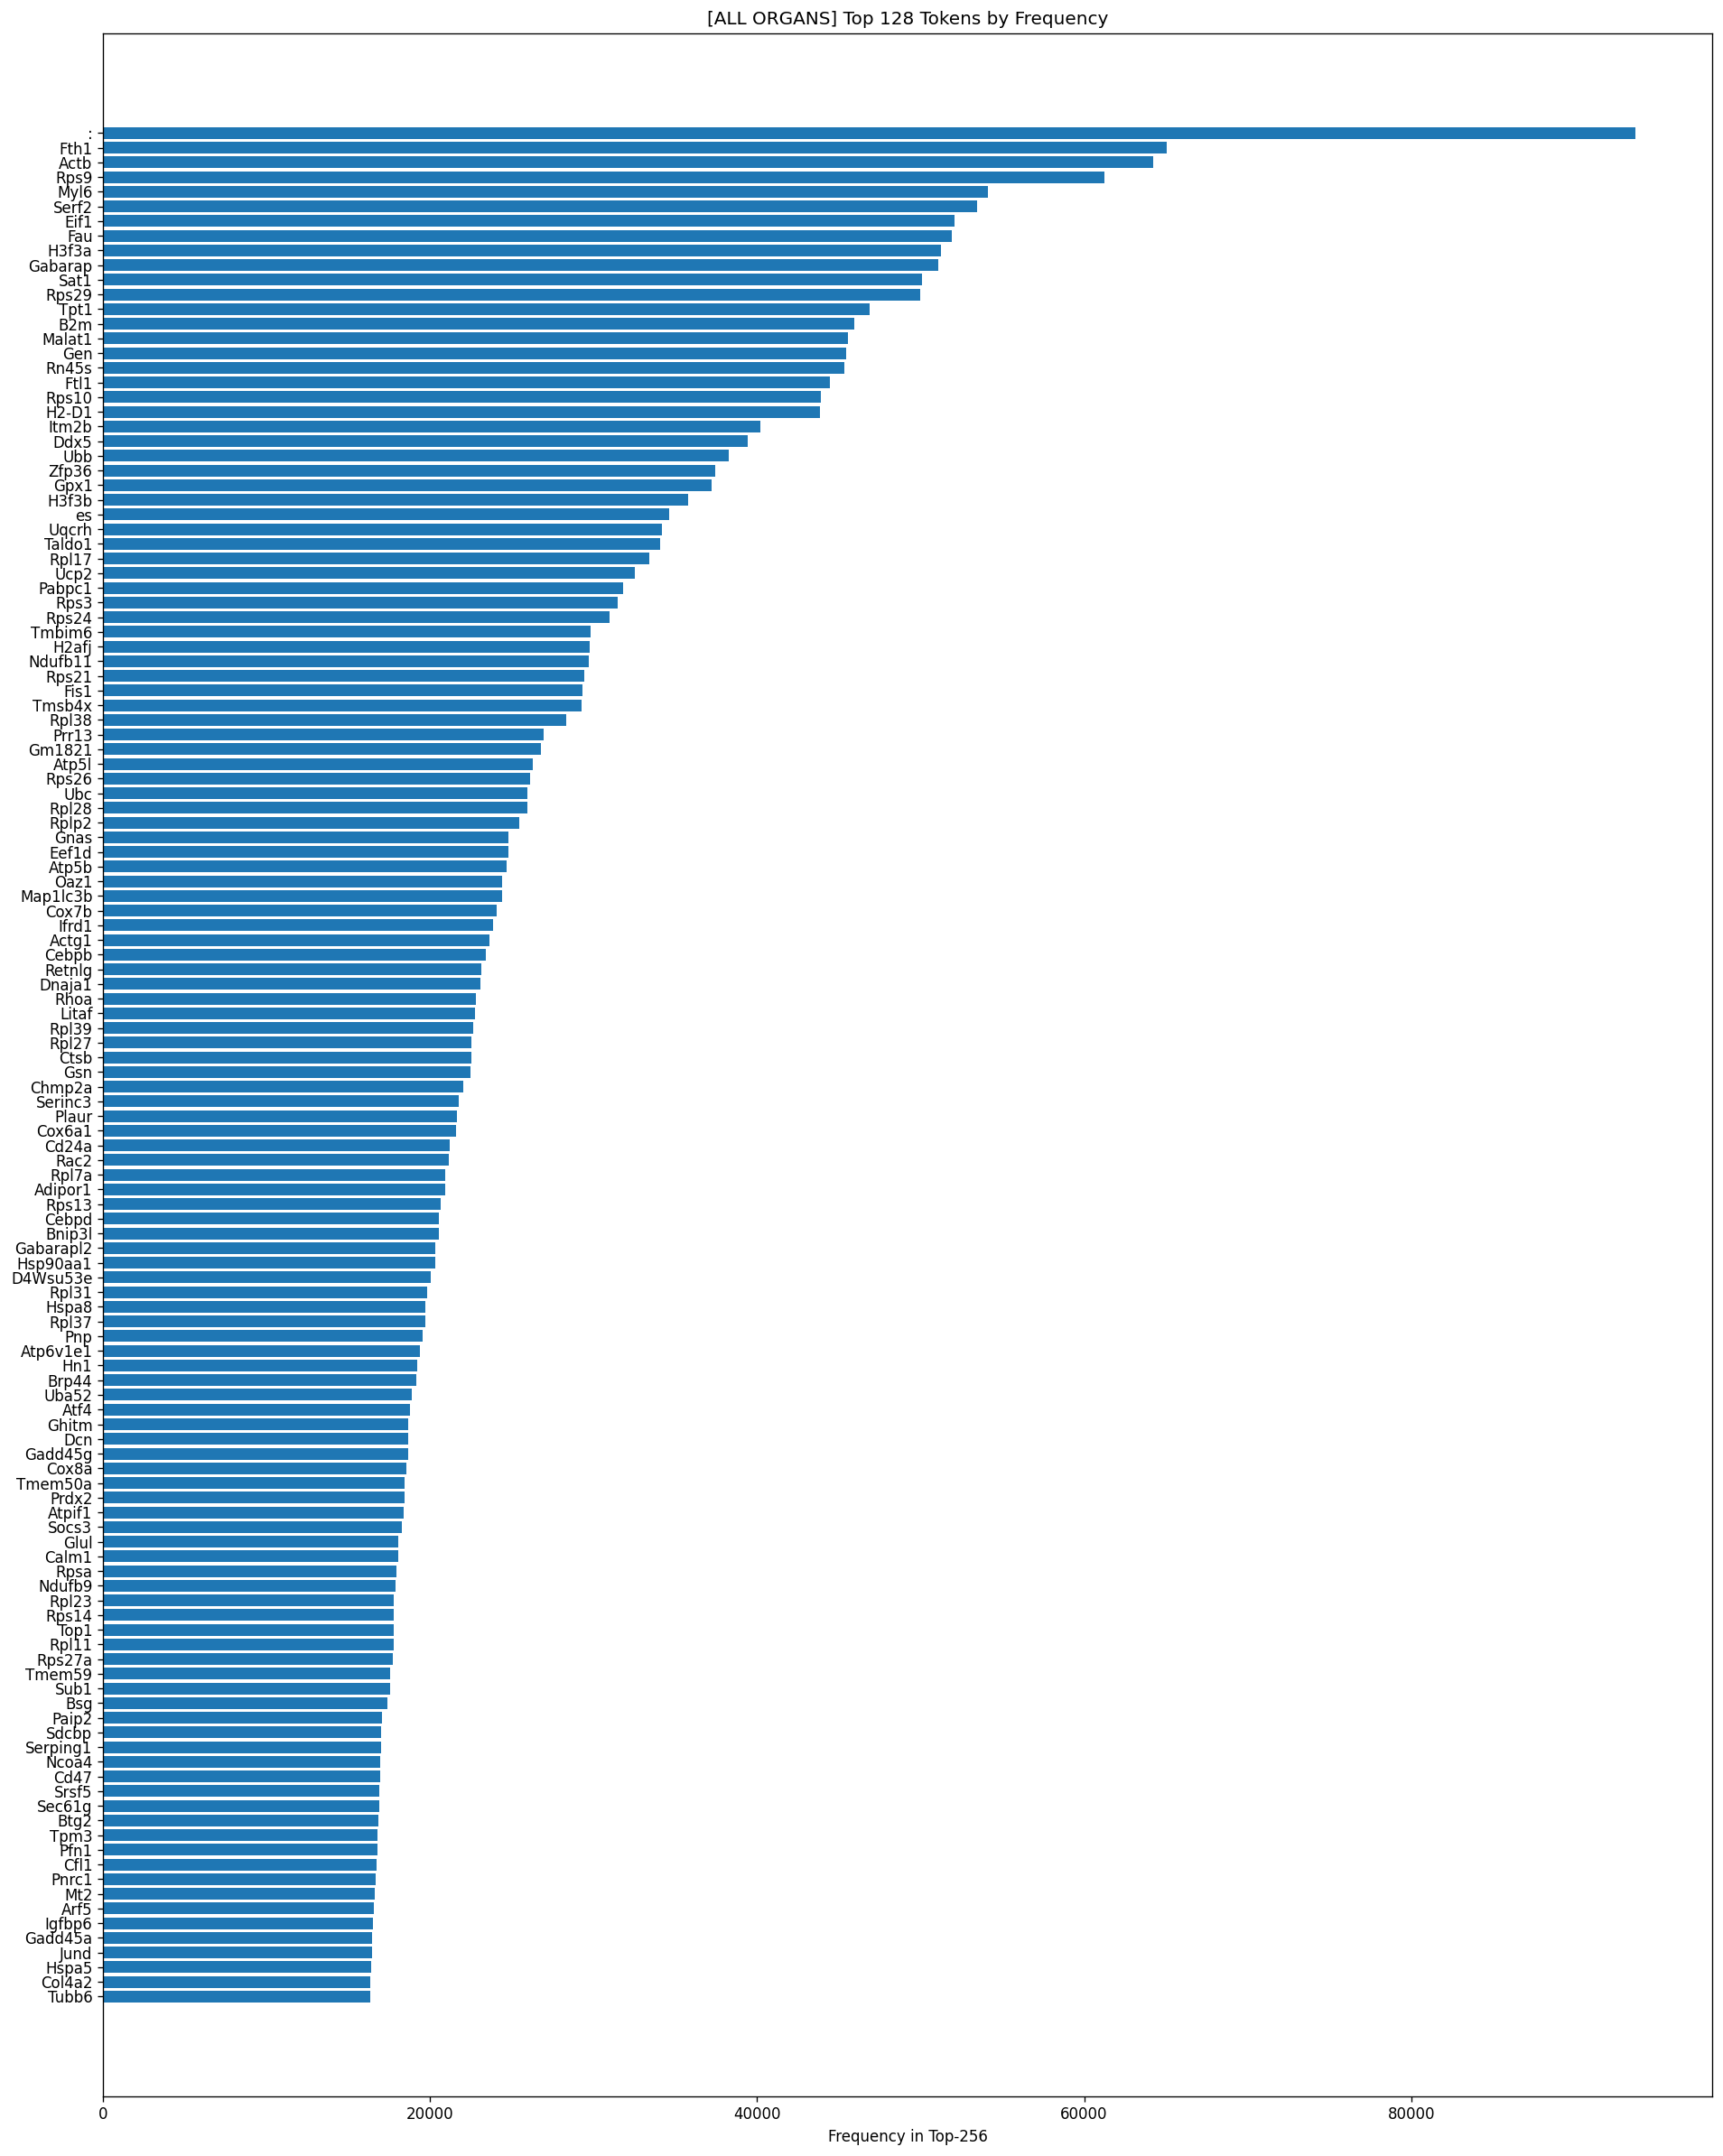


--- 4. Top 128 tokens by total score (all organs) ---
  ':': 18278.7195
  'Fth1': 15571.1748
  'Actb': 15521.5247
  'Rps29': 13655.6772
  'Rn45s': 13066.4487
  'Sat1': 11151.1353
  'Fau': 11146.9414
  'Tpt1': 11098.5039
  'Eif1': 10694.9482
  'Zfp36': 8145.9375
  'H3f3a': 7925.6160
  'Rps10': 7876.7483
  'Rps9': 7733.4153
  'Serf2': 7616.2341
  'Retnlg': 7593.5247
  'Dbp': 7504.1196
  'Entpd2': 7388.9783
  'Gen': 7379.9358
  'Rps3': 7006.6809
  'Myl6': 6898.9302
  'Malat1': 6824.5090
  'Col1a1': 6795.5769
  'Gabarap': 6736.9993
  'Dcn': 6696.4143
  'Ubb': 6632.4221
  'H2-D1': 6466.2007
  'B2m': 6293.6465
  'Ftl1': 6056.3057
  'Tnfsf9': 6037.1050
  'Car2': 5853.0176
  'Hmox1': 5765.1196
  'Taldo1': 5662.3445
  'Gsn': 5645.4043
  'Rpl28': 5328.9121
  'Itm2b': 5222.0740
  'Rplp2': 5081.8256
  'Gpx1': 4961.3350
  'Col4a2': 4943.8230
  'Ddx5': 4877.9773
  'Serinc3': 4785.2198
  'Cxcl1': 4781.3665
  'Rpl17': 4718.1577
  'Ndufb11': 4693.5211
  'Rpl38': 4666.5590
  'Gm1821': 4533.1379
  'Plau

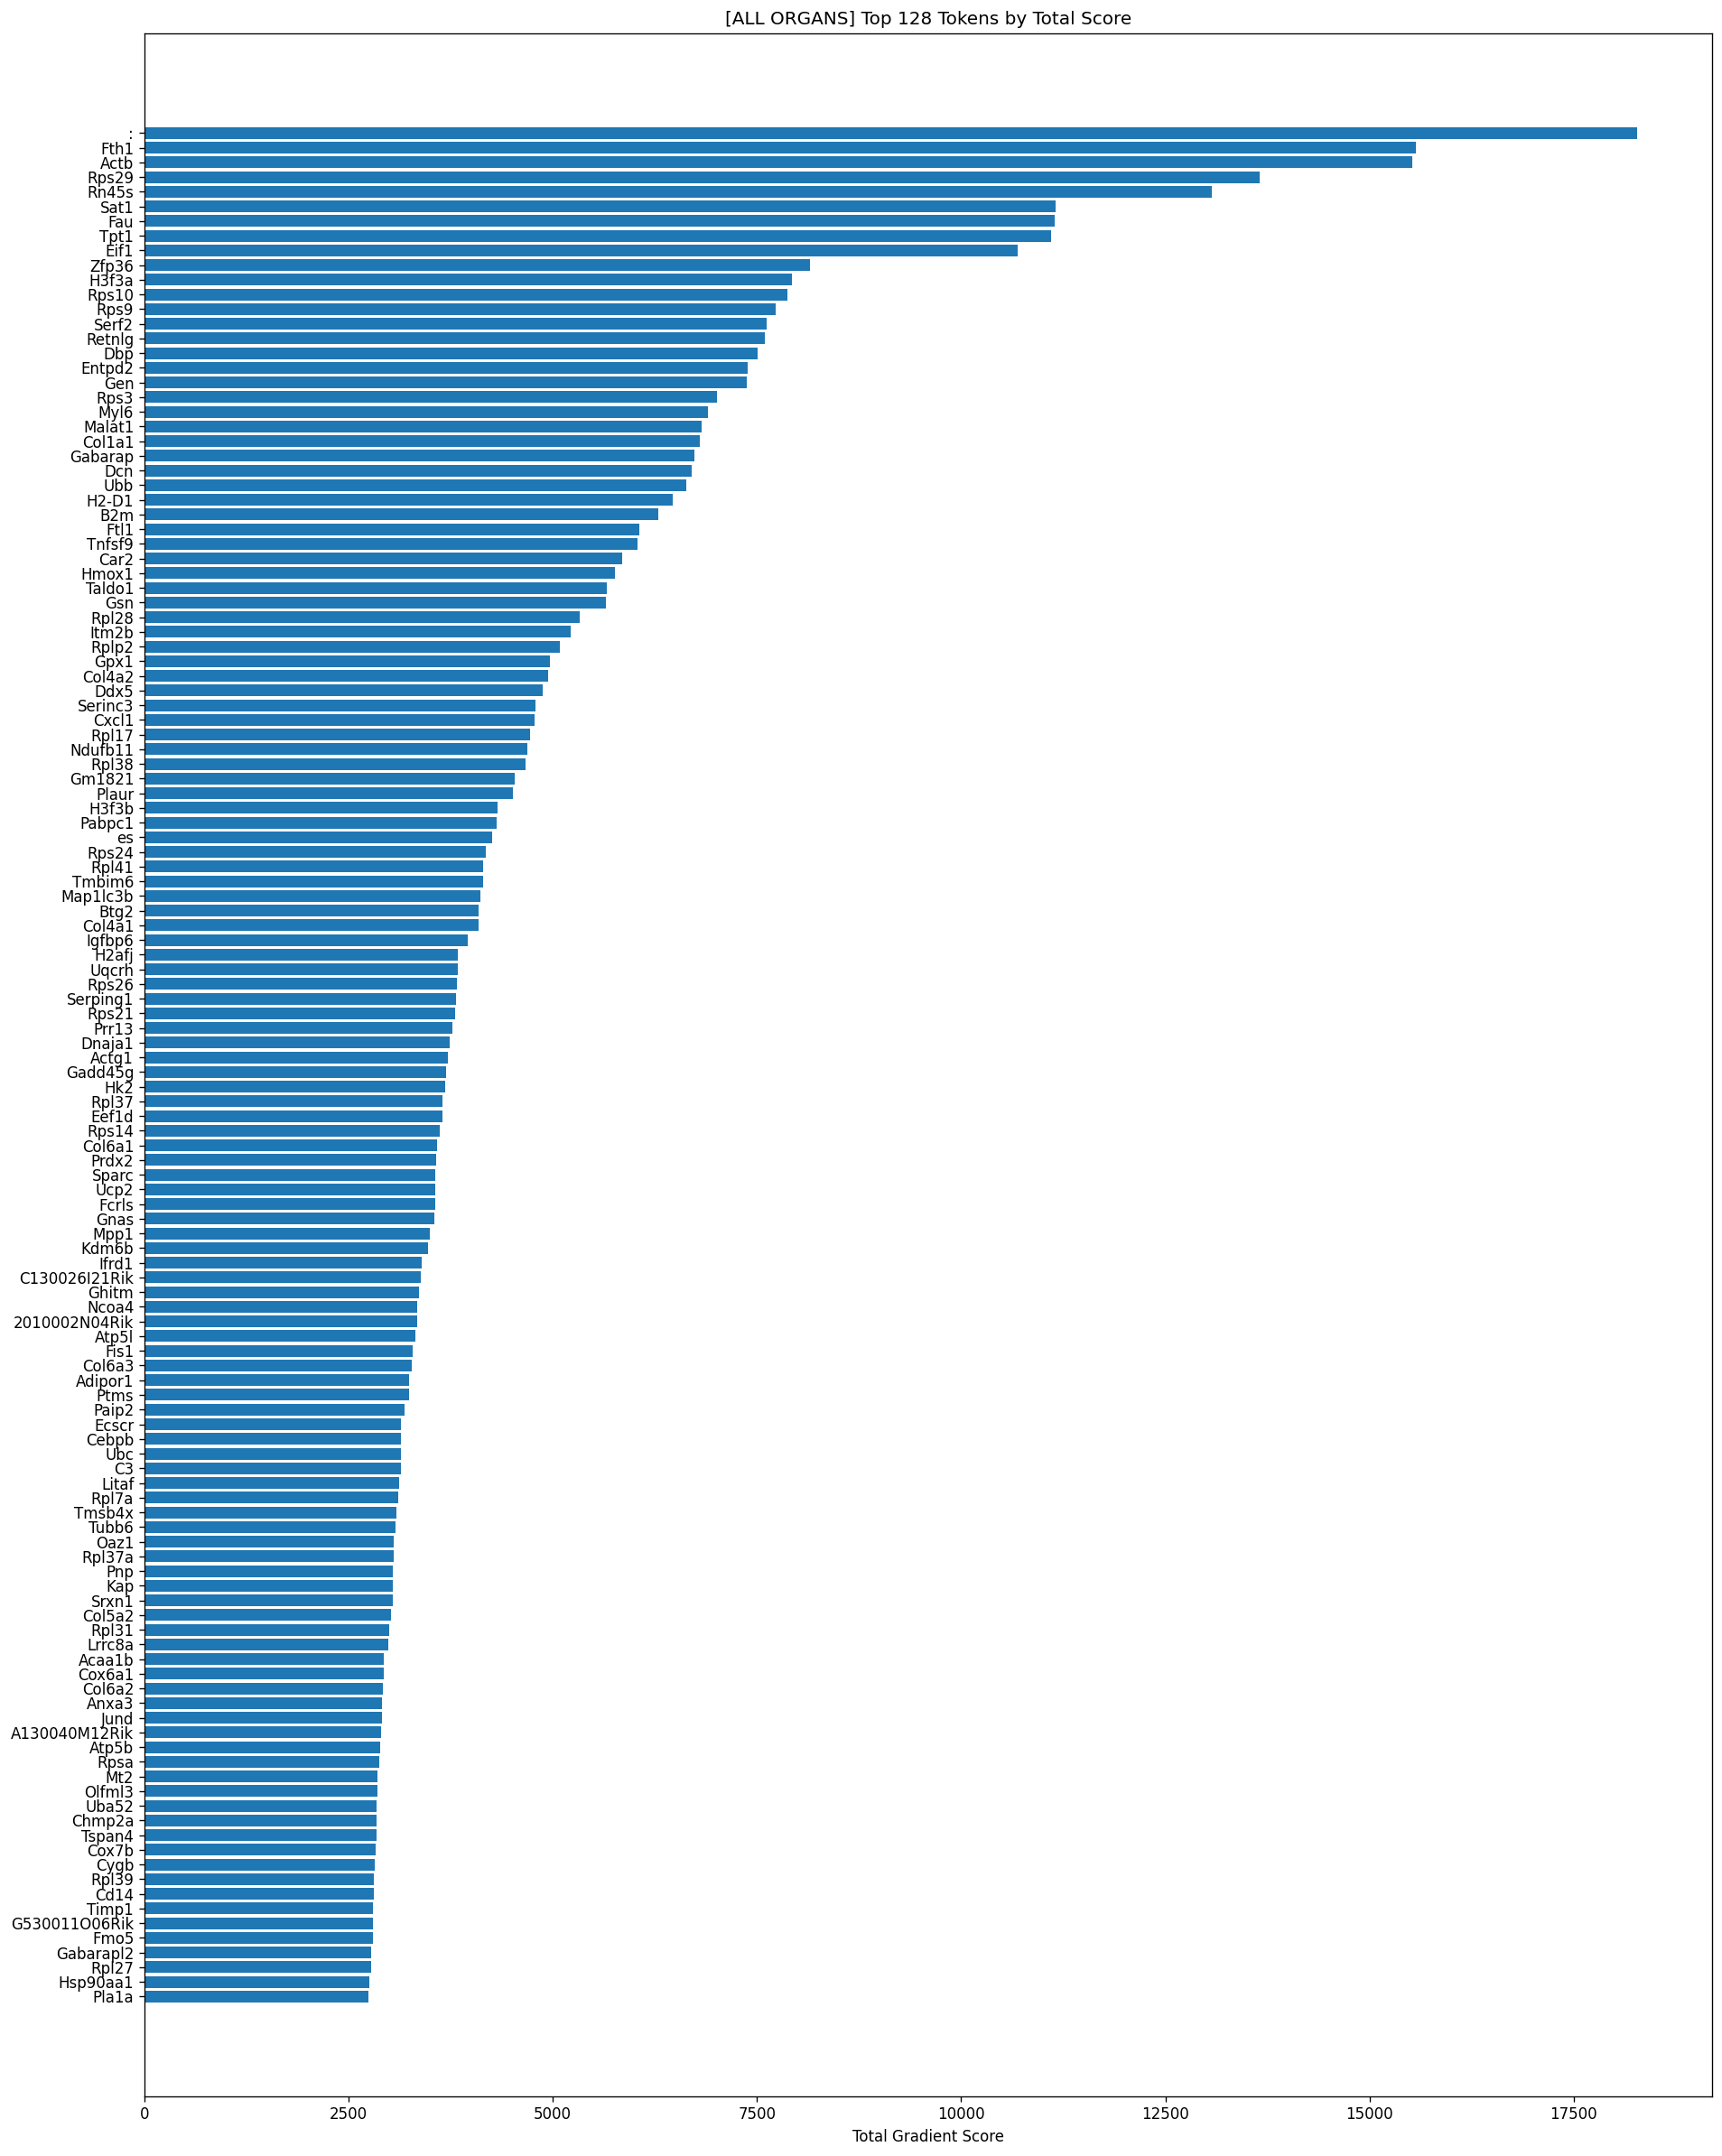


--- 4c. Avg frequency in top-256 (global) ---
  ':': 0.9945
  'Fth1': 0.6903
  'Actb': 0.6816
  'Rps9': 0.6500
  'Myl6': 0.5745
  'Serf2': 0.5671
  'Eif1': 0.5525
  'Fau': 0.5507
  'H3f3a': 0.5435
  'Gabarap': 0.5422
  'Sat1': 0.5317
  'Rps29': 0.5303
  'Tpt1': 0.4974
  'B2m': 0.4873
  'Malat1': 0.4834
  'Gen': 0.4822
  'Rn45s': 0.4811
  'Ftl1': 0.4718
  'Rps10': 0.4659
  'H2-D1': 0.4650
  'Itm2b': 0.4265
  'Ddx5': 0.4184
  'Ubb': 0.4060
  'Zfp36': 0.3972
  'Gpx1': 0.3950
  'H3f3b': 0.3796
  'es': 0.3672
  'Uqcrh': 0.3629
  'Taldo1': 0.3613
  'Rpl17': 0.3544
  'Ucp2': 0.3452
  'Pabpc1': 0.3373
  'Rps3': 0.3339
  'Rps24': 0.3289
  'Tmbim6': 0.3163
  'H2afj': 0.3158
  'Ndufb11': 0.3150
  'Rps21': 0.3123
  'Fis1': 0.3112
  'Tmsb4x': 0.3106
  'Rpl38': 0.3005
  'Prr13': 0.2860
  'Gm1821': 0.2841
  'Atp5l': 0.2788
  'Rps26': 0.2773
  'Ubc': 0.2753
  'Rpl28': 0.2752
  'Rplp2': 0.2700
  'Gnas': 0.2633
  'Eef1d': 0.2632
  'Atp5b': 0.2617
  'Oaz1': 0.2589
  'Map1lc3b': 0.2587
  'Cox7b': 0.2554


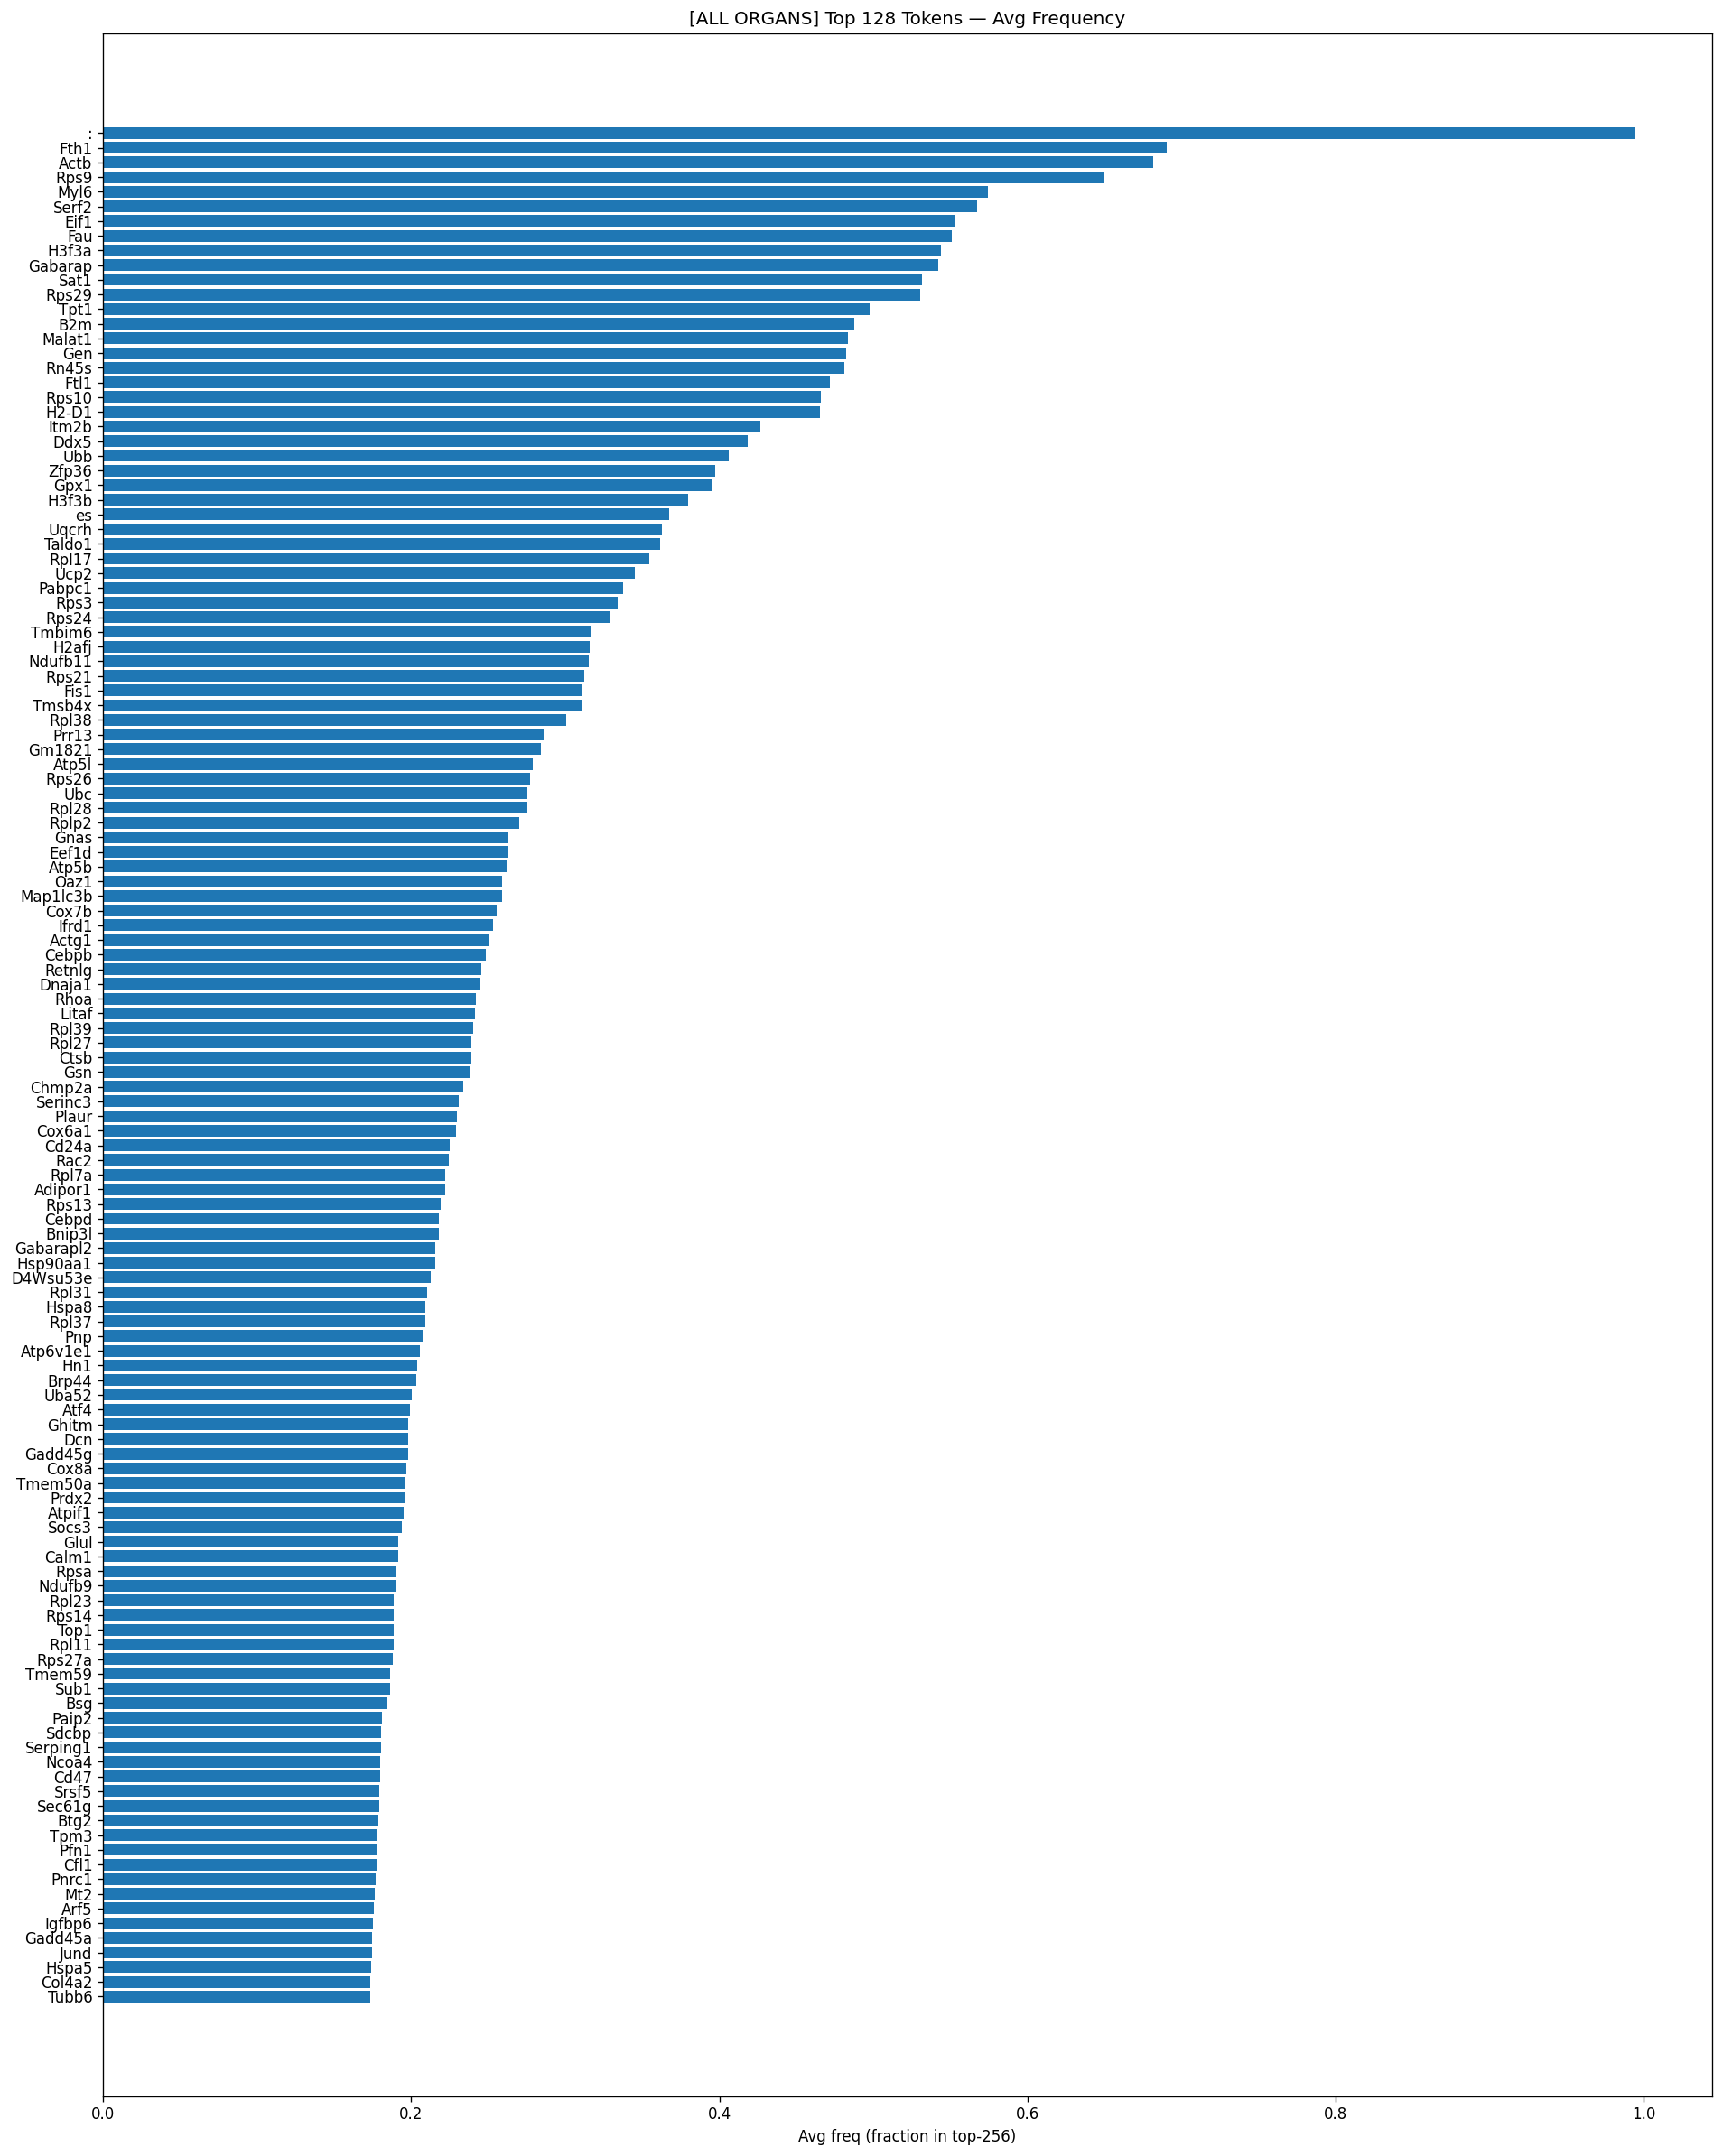


--- 6. Word cloud (all organs, by total score) ---


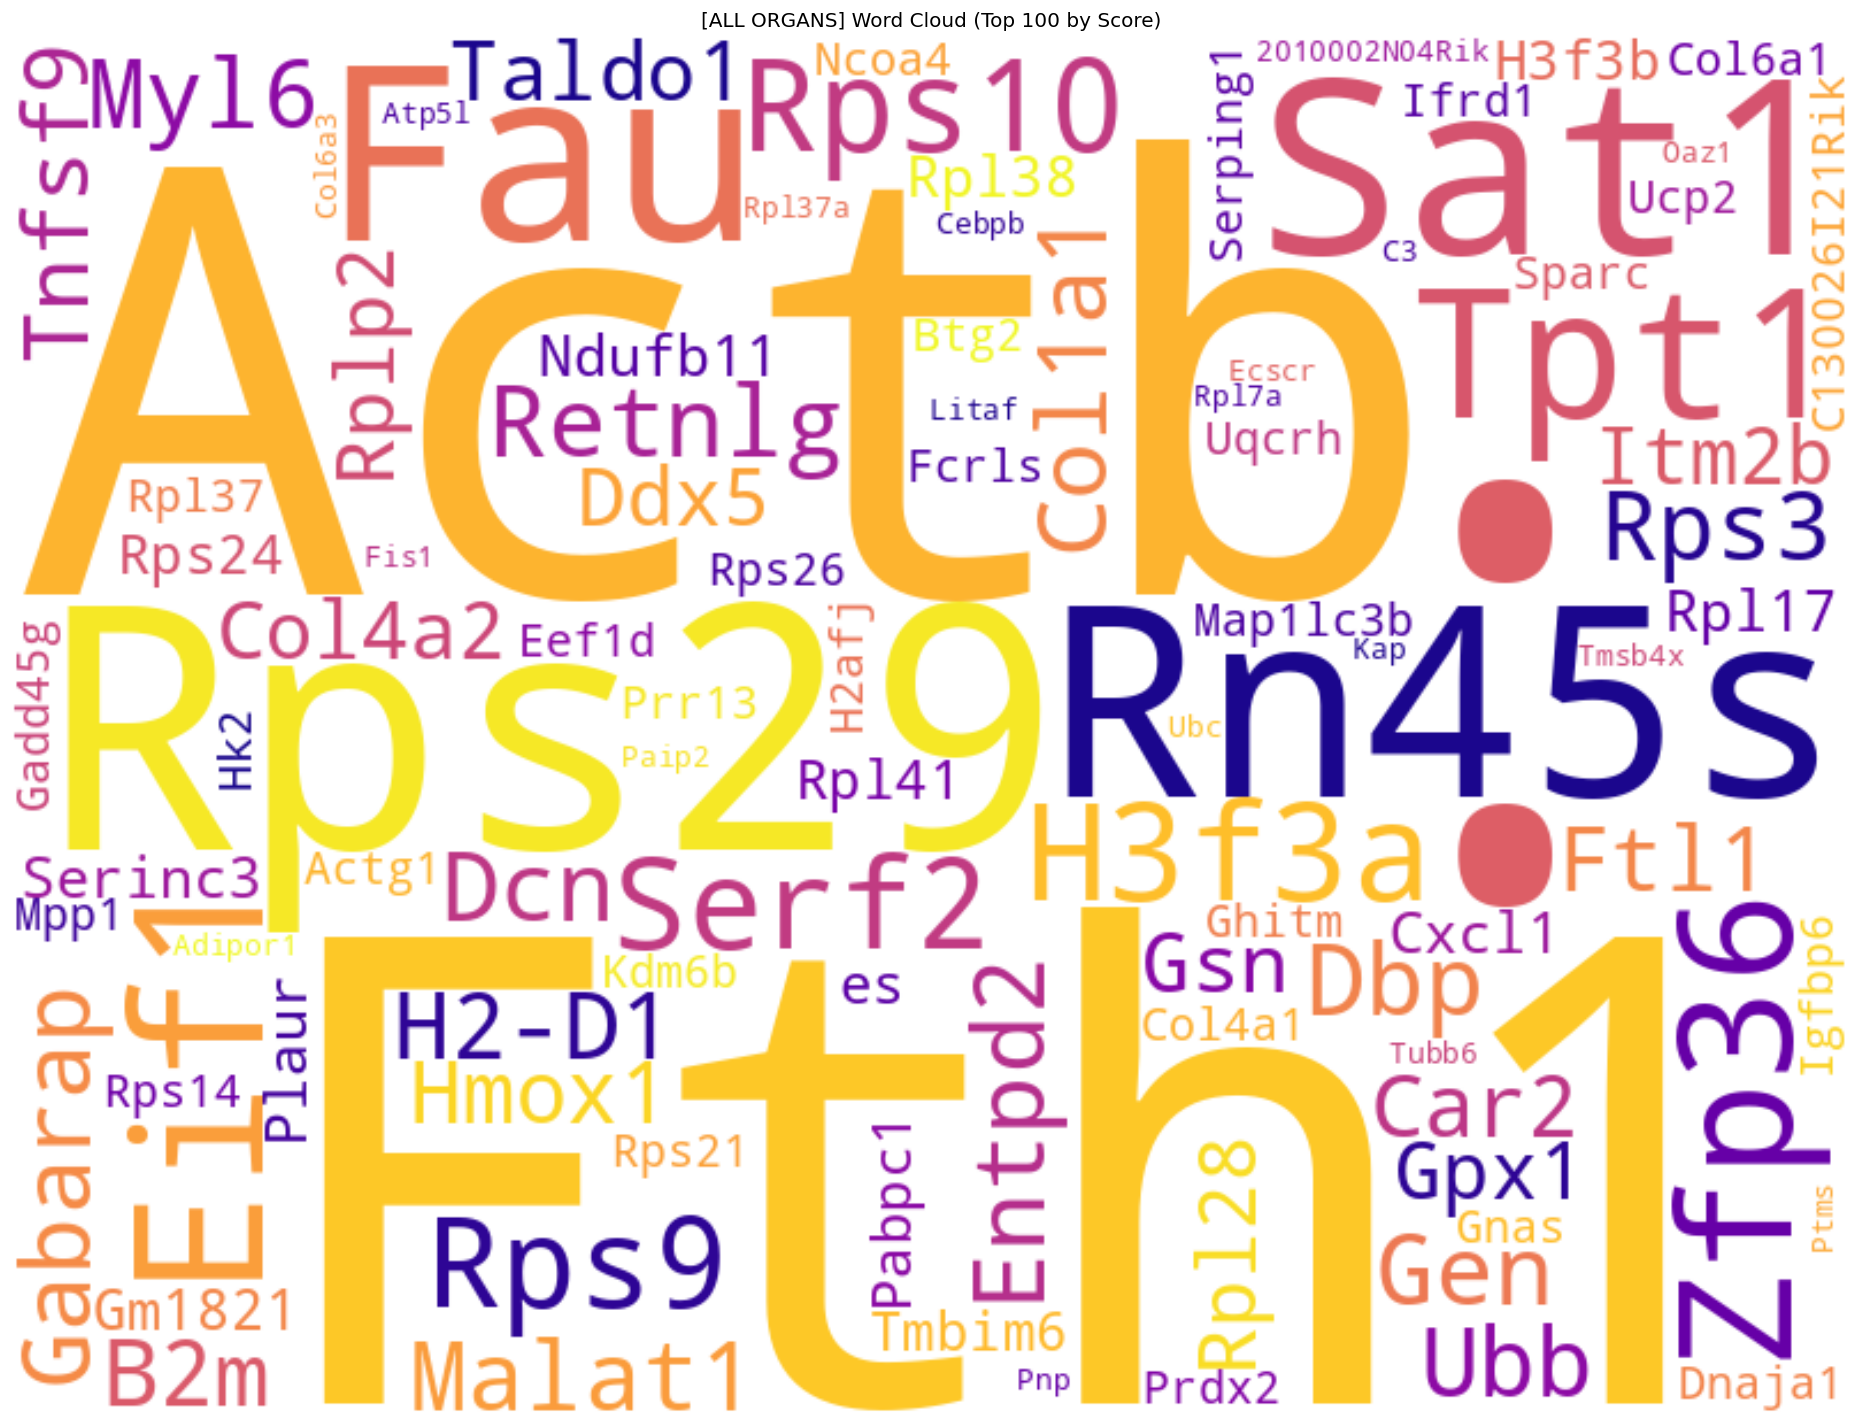


VISUALIZATION COMPLETE


ValueError: too many values to unpack (expected 2)

In [ ]:
# ============================================================
# BLOCK 3: Visualize + organ specificity (inline, no file I/O)
# ============================================================

# ── 3a. All visualizations (inline) ──────────────────────────────────────────
print("Generating visualizations...")
organ_top_scores_full, global_top_scores_full = visualize_results(
    full_results, organ_keys, out_dir=None   # None → no PNG files written
)

# # ── 3b. Organ specificity analysis + overlap heatmap ─────────────────────────
# print("\nRunning organ specificity analysis...")
# specificity_results = analyze_organ_specificity(
#     full_results, organ_keys, topk=100, out_dir=None
# )

# ── 3c. Print full summary tables inline ─────────────────────────────────────
print("\n" + "="*70)
print("SUMMARY: TOP-128 TOKENS PER ORGAN (by avg gradient score)")
print("="*70)
for organ in organ_keys:
    src = full_results.get("organ_scores_avg", {})
    if organ not in src:
        continue
    top128 = Counter(src[organ]).most_common(128)
    print(f"\n[{organ.upper()}]")
    hdr = f"  {'Rank':<5} {'Token':<30} {'Avg Grad Score':>16}  {'Freq (total)':>12}"
    print(hdr)
    print("  " + "-" * (len(hdr) - 2))
    freq_src = full_results.get("organ_freq", {}).get(organ, {})
    for rank, (token, score) in enumerate(top128, 1):
        freq = freq_src.get(token, 0)
        print(f"  {rank:<5} {token:<30} {score:>16.6f}  {freq:>12}")

print("\n" + "="*70)
print("SUMMARY: TOP-128 TOKENS GLOBAL (by avg gradient score, all organs)")
print("="*70)
global_avg_top = Counter(full_results.get("global_scores_avg", {})).most_common(128)
hdr = f"  {'Rank':<5} {'Token':<30} {'Avg Grad Score':>16}  {'Total Freq':>10}  {'Organs':>6}"
print(hdr)
print("  " + "-" * (len(hdr) - 2))
toc = specificity_results.get("token_organ_count", {})
gfreq = full_results.get("global_freq", {})
for rank, (token, score) in enumerate(global_avg_top, 1):
    freq = gfreq.get(token, 0)
    n_organs = toc.get(token, "?")
    print(f"  {rank:<5} {token:<30} {score:>16.6f}  {freq:>10}  {n_organs:>6}")

print("\n" + "="*70)
print("SUMMARY: UNIVERSAL TOKENS (in top-100 for ALL organs)")
print("="*70)
universal = specificity_results.get("universal_tokens", [])
print(f"  Total: {len(universal)}")
for i, t in enumerate(universal, 1):
    print(f"  {i:>3}. '{t}'")

print("\n" + "="*70)
print("SUMMARY: ORGAN-EXCLUSIVE TOKENS (unique to each organ's top-100)")
print("="*70)
exclusive = specificity_results.get("exclusive_tokens", {})
for organ in organ_keys:
    excl = exclusive.get(organ, [])
    print(f"\n  [{organ.upper()}] {len(excl)} exclusive tokens:")
    for i, t in enumerate(excl, 1):
        score = full_results.get("organ_scores_avg", {}).get(organ, {}).get(t, 0)
        print(f"    {i:>3}. '{t}'  (avg score: {score:.6f})")

torch_xla.sync()
print("\n" + "="*70)
print("FULL ANALYSIS + ORGAN SPECIFICITY COMPLETE")
print("="*70)


In [ ]:
# ============================================================
# TOP-2048 GLOBAL AVERAGE GRADIENT SCORE TOKENS
# Ranked list of gene tokens by avg gradient importance across all organs.
# ============================================================
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

_gsa = full_results.get('global_scores_avg', {})
if not _gsa:
    print('[WARN] global_scores_avg empty — run Block 2 first.')
else:
    top2048 = Counter(_gsa).most_common(2048)
    n_unique = len(_gsa)

    # ── Text table (all 2048) ─────────────────────────────────────────────────
    print('=' * 70)
    print('TOP-2048 GENE TOKENS BY AVERAGE GRADIENT IMPORTANCE (ALL ORGANS)')
    print('=' * 70)
    print(f'Total unique tokens tracked: {n_unique}  |  Reporting top {len(top2048)}\n')
    hdr = '{:<6} {:<35} {:>18}'.format('Rank', 'Token', 'Avg Grad Score')
    print(hdr)
    print('-' * len(hdr))
    for rank, (token, score) in enumerate(top2048, 1):
        print(f'{rank:<6} {token:<35} {score:>18.6f}')
    print('\n' + '=' * 70)

    # ── Bar chart: top-128 by avg gradient score ──────────────────────────────
    top128 = top2048[:128]
    tokens_128  = [t for t, _ in top128]
    scores_128  = [s for _, s in top128]
    # reverse for horizontal bar (highest at top)
    tokens_128r = tokens_128[::-1]
    scores_128r = scores_128[::-1]

    fig, ax = plt.subplots(figsize=(14, 40))
    bars = ax.barh(range(len(tokens_128r)), scores_128r, color='steelblue')
    ax.set_yticks(range(len(tokens_128r)))
    ax.set_yticklabels(tokens_128r, fontsize=9)
    ax.set_xlabel('Avg Gradient Score (all organs)', fontsize=11)
    ax.set_title('Top-128 Gene Tokens — Avg Gradient Importance (All Organs)', fontsize=13)
    # Annotate each bar with its rank
    for i, (bar, score) in enumerate(zip(bars, scores_128r)):
        rank = len(top128) - i
        ax.text(bar.get_width() * 1.005, bar.get_y() + bar.get_height() / 2,
                f'#{rank}  {score:.4f}', va='center', fontsize=7.5)
    plt.tight_layout()
    plt.show()

    # ── Score distribution (log-scale histogram) ─────────────────────────────
    all_scores = [s for _, s in top2048]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(all_scores, bins=80, color='teal', edgecolor='white', linewidth=0.4)
    ax.set_yscale('log')
    ax.set_xlabel('Avg Gradient Score', fontsize=11)
    ax.set_ylabel('Count (log scale)', fontsize=11)
    ax.set_title('Distribution of Avg Gradient Scores — Top-2048 Tokens', fontsize=12)
    plt.tight_layout()
    plt.show()

    # ── Cumulative score coverage ─────────────────────────────────────────────
    total_score = sum(all_scores)
    cum_frac = np.cumsum(all_scores) / total_score
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(range(1, len(cum_frac) + 1), cum_frac * 100, color='darkorange', linewidth=1.5)
    for pct, color in [(50, 'blue'), (80, 'green'), (95, 'red')]:
        idx = np.searchsorted(cum_frac, pct / 100)
        ax.axvline(idx + 1, linestyle='--', color=color, linewidth=1,
                   label=f'{pct}% coverage @ rank {idx+1}')
    ax.set_xlabel('Token rank (by avg score)', fontsize=11)
    ax.set_ylabel('Cumulative score coverage (%)', fontsize=11)
    ax.set_title('Cumulative Score Coverage — Top-2048 Tokens', fontsize=12)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    print(f'\nScore statistics:')
    print(f'  Top-1  token: {top2048[0][0]!r:35s}  score={top2048[0][1]:.6f}')
    print(f'  Top-10 cumulative fraction: {cum_frac[9]*100:.1f}%')
    print(f'  Top-128 cumulative fraction: {cum_frac[127]*100:.1f}%')
    print(f'  Top-100 cumulative fraction: {cum_frac[99]*100:.1f}%')
    if len(cum_frac) >= 2048:
        print(f'  Top-2048 cumulative fraction: {cum_frac[2047]*100:.1f}%')


In [1]:
import pickle
import os

# Define the path to save the results in Google Drive
output_dir = "/content/drive/MyDrive/aging_prediction_results"
os.makedirs(output_dir, exist_ok=True)

file_path = os.path.join(output_dir, "full_gradient_analysis_results.pkl")

# Save the full_results dictionary
with open(file_path, "wb") as f:
    pickle.dump(full_results, f)

print(f"Full gradient analysis results saved to: {file_path}")

NameError: name 'full_results' is not defined

In [ ]:
# # # delete run time when finished
# from google.colab import runtime
# runtime.unassign()